<a href="https://colab.research.google.com/github/Lucas-Rattighieri/falqon-portfolio-optimization/blob/main/Portif%C3%B3lio_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Instação das Bibliotecas

%%capture

!pip install -q git+https://github.com/Lucas-Rattighieri/qtsuru

!pip install -q   "qiskit==1.3.1" \
                "qiskit-finance==0.4.1" \
                "qiskit-optimization[cplex]" \
                "jax==0.4.23" \
                "dimod"


In [ ]:
#@title Importação das Bibliotecas

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import numpy as np
import numpy.linalg as npl
import scipy.linalg as la
import torch
import itertools
from scipy.optimize import minimize
import networkx as nx
import os
import pandas as pd

import datetime
import itertools
from collections import Counter

# Importação da qtsuru
import qtsuru
from qtsuru import Hamiltonian
from qtsuru import DiagonalOps
from qtsuru import BitOps
from qtsuru import Htsp
from qtsuru import BufferManager
from qtsuru import Operators
from qtsuru import Hamiltonian

# Qiskit Finance
from qiskit_finance.data_providers import RandomDataProvider
from qiskit_finance.applications.optimization import PortfolioOptimization

# Qiskit Optimization
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.translators import from_docplex_mp
from qiskit_optimization.algorithms import CplexOptimizer, MinimumEigenOptimizer

# Qiskit Algorithms
from qiskit_algorithms import NumPyMinimumEigensolver

# Qiskit result
from qiskit.result import QuasiDistribution

# Docplex
from docplex.mp.model import Model

dtype = torch.complex128
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#@title H warm-starting

class Hwarm(Hamiltonian):


    def __init__(self, L: int, cs, epsilon =  0, device="cpu"):

        super().__init__(L, device)

        self.ops = Operators(L, device)

        self.epsilon = torch.tensor(epsilon, device = device)
        self.cs = cs
        self.thetas = self.calcular_thetas()


    def calcular_thetas(self):

        thetas = [0] * len(self.cs)

        for i, ci in enumerate(self.cs):
            if ci <= self.epsilon:
                pi = self.epsilon
            elif ci < 1 - self.epsilon:
                pi = torch.tensor(ci, device=self.device) if not isinstance(ci, torch.Tensor) else ci
            else:
                pi = 1 - self.epsilon

            thetas[i] = torch.asin(torch.sqrt(pi))
        return thetas



    def hamiltonian(self, psi, out=None):

        if out is None:
            out = torch.zeros_like(psi)
        else:
            out.zero_()

        tmppsi = self.manager.get()

        for qubit in range(self.L):
            mcthetai = -torch.cos(self.thetas[qubit])
            msthetai = -torch.sin(self.thetas[qubit])

            self.ops.X(psi, qubit, out=tmppsi)
            out.add_(tmppsi, alpha=msthetai)
            self.ops.Z(psi, qubit, out=tmppsi)
            out.add_(tmppsi, alpha=mcthetai)

        self.manager.release(tmppsi)
        return out


    def evolution(self, psi, time, out=None):


        tmppsi1 = self.manager.get()
        tmppsi2 = self.manager.get()

        tmppsi1.copy_(psi)

        for qubit in range(self.L):
            self.ops.Ry(tmppsi1, -self.thetas[qubit], qubit, out=tmppsi2)
            self.ops.Rz(tmppsi2, -2 * time, qubit, out=tmppsi1)
            self.ops.Ry(tmppsi1, self.thetas[qubit], qubit, out=tmppsi2)
            tmppsi2, tmppsi1 = tmppsi1, tmppsi2

        if out is None:
            out = tmppsi1.clone()
        else:
            out.copy_(tmppsi1)

        self.manager.release(tmppsi1)
        self.manager.release(tmppsi2)
        return out

In [ ]:
#@title Hxy

class Hxy(Hamiltonian):


    def __init__(self, L: int, alpha = 1, device="cpu"):

        super().__init__(L, device)

        self.ops = Operators(L, device)
        self.alpha = alpha



    def hamiltonian(self, psi, out=None):

        if out is None:
            out = torch.zeros_like(psi)
        else:
            out.zero_()

        tmppsi = self.manager.get()

        for qubit_i in range(self.L):
            for qubit_j in range(qubit_i + 1, self.L):

                self.ops.X(psi, [qubit_i, qubit_j], out=tmppsi)
                out.add_(tmppsi)
                self.ops.Y(psi, [qubit_i, qubit_j], out=tmppsi)
                out.add_(tmppsi)

        out.mul_(0.5)

        self.manager.release(tmppsi)
        return out


    def evolution(self, psi, time, out=None):

        if not isinstance(time, torch.Tensor):
            theta = torch.tensor(time, dtype=self.dtype, device=self.device)
        else:
            theta = time.to(dtype=self.dtype, device=self.device)


        ctheta = torch.cos(theta / (self.alpha))
        istheta = -1j * torch.sin(theta / (self.alpha))

        tmppsi1 = self.manager.get()
        tmppsi2 = self.manager.get()
        tmppsi3 = self.manager.get()

        tmp1 = self.ops.int_manager.get()
        tmp2 = self.ops.int_manager.get()

        tmppsi1.copy_(psi)

        for qubit_i in range(self.L):
            for qubit_j in range(qubit_i + 1,self.L):

                self.ops.bitops.xor_bits(self.ops.indices, [qubit_i, qubit_j], out=tmp1)
                torch.bitwise_xor(tmp1, 1, out=tmp2)
                self.ops.X(tmppsi1, [qubit_i, qubit_j], out=tmppsi2)

                torch.mul(tmp1, ctheta, out=tmppsi3)
                tmppsi3.add_(tmp2)

                tmppsi1.mul_(tmppsi3)

                torch.mul(tmppsi2, tmp1, out=tmppsi3)
                tmppsi1.add_(tmppsi3, alpha=istheta)



        if out is None:
            out = tmppsi1.clone()
        else:
            out.copy_(tmppsi1)

        self.manager.release(tmppsi1)
        self.manager.release(tmppsi2)
        self.manager.release(tmppsi3)
        self.ops.int_manager.release(tmp1)
        self.ops.int_manager.release(tmp2)
        return out

In [ ]:
#@title Hportifolio

class Hportifolio(Hamiltonian):


    def __init__(self,
                 num_assets: int,
                 covariance,
                 asset_returns,
                 weigth: float = 1,
                 lamb: float = 1,
                 eta: float = 1,
                 B: int = None,
                 device="cpu"):

        self.num_assets = num_assets
        self.covariance = covariance
        self.asset_returns = asset_returns

        self.weigth = weigth
        self.lamb = lamb
        self.eta = eta
        self.B = B


        L = num_assets

        super().__init__(L, device)

        self.diag = DiagonalOps(L, self.device)
        self.diag_hamiltonian = torch.empty(2**L, device=self.device, dtype=self.dtype)
        self.create_diagonal_hamiltonian()


    def _index(self, asset):

        return asset


    def create_diagonal_hamiltonian(self):

        self.diag_hamiltonian.zero_()
        out_restriction = self.manager.get()
        out_restriction.zero_()
        out_chain = self.manager.get()


        for asset_i in range(self.num_assets):
            index_i = self._index(asset_i)

            self.diag.number_chain([index_i], out=out_chain)

            out_restriction.add_(out_chain)
            self.diag_hamiltonian.add_(out_chain, alpha=-self.asset_returns[asset_i])
            self.diag_hamiltonian.add_(out_chain, alpha=self.lamb * self.covariance[asset_i, asset_i])

            for asset_j in range(asset_i + 1, self.num_assets):

                index_j = self._index(asset_j)

                if self.covariance[asset_i, asset_j] != 0:
                    self.diag.number_chain([index_i, index_j], 2 * self.lamb * self.covariance[asset_i, asset_j], out=out_chain)

                    self.diag_hamiltonian.add_(out_chain)


        out_restriction.sub_(self.B)
        out_restriction.pow_(2)

        self.diag_hamiltonian.add_(out_restriction, alpha=self.eta)


        if self.weigth != 1:
            self.diag_hamiltonian.mul_(self.weigth)

        self.manager.release(out_chain)
        self.manager.release(out_restriction)
        return self.diag_hamiltonian


    def hamiltonian(self, psi, out=None):

        if out is None:
            out = torch.empty_like(psi)

        torch.mul(psi, self.diag_hamiltonian, out=out)
        return out


    def evolution(self, psi, time, out=None):

        if out is None:
            out = torch.empty_like(psi)

        torch.mul(self.diag_hamiltonian, -1j * time, out=out)
        out.exp_()
        out.mul_(psi)
        return out


    def selected_assets(self, state):

        sel_assets = []

        for i in range(self.L):
            if (state >> i) & 1:
                sel_assets.append(i)
        return sel_assets

In [ ]:
#@title Warm Starting


def prob_estado_base(psi : torch.Tensor, estado : int):

    return float(torch.abs(psi[estado]) ** 2)



def warm_starting(L, cs, epsilon = 0, device = "cpu", out = None):
    epsilon = torch.tensor(epsilon, device = device)

    op = qtsuru.Operators(L, device)
    bt = op.bitops

    buffer1 = op.manager.get()
    buffer2 = op.manager.get()
    buffer1.zero_()
    buffer1[0] = 1



    for i, ci in enumerate(cs):
        if ci <= epsilon:
            pi = epsilon
        elif ci < 1 - epsilon:
            pi = torch.tensor(ci, device=device) if not isinstance(ci, torch.Tensor) else ci
        else:
            pi = 1 - epsilon

        theta_i = torch.asin(torch.sqrt(pi))

        op.Ry(buffer1, 2 * theta_i, i, out = buffer2)
        buffer1, buffer2 = buffer2, buffer1

    if out is None:
        out = buffer1.clone()
    else:
        out.copy_(buffer1)

    op.manager.release(buffer1)
    op.manager.release(buffer2)

    return out

In [ ]:
#@title Problema relaxado

def create_continuous_portfolio_problem(mu, Sigma, lam, B):
    # n é o número de ativos, determinado pelo tamanho do vetor mu
    n = len(mu)
    # Cria um modelo de otimização contínua com o nome "PortfolioRelaxed"
    mdl = Model(name="PortfolioRelaxed")

    # Define as variáveis contínuas x_i no intervalo [0, 1] para cada ativo
    x = [mdl.continuous_var(lb=0, ub=1, name=f"x{i}") for i in range(n)]

    # Adiciona a restrição de que a soma dos x deve ser igual a B (orçamento fracionário)
    mdl.add_constraint(mdl.sum(x) == B)

    # Inicializa o termo de risco (parte da função objetivo)
    risk = 0
    for i in range(n):
        # Adiciona o termo diagonal
        risk += lam * Sigma[i, i] * x[i] * x[i]
        # Para os termos fora da diagonal, soma os termos duas vezes (simetria)
        for j in range(i+1, n):
            risk += 2 * lam * Sigma[i, j] * x[i] * x[j]

    # Inicializa o termo de retorno (parte da função objetivo)
    ret = 0
    for i in range(n):
        ret += - mu[i] * x[i]

    # Define a função objetivo do modelo como a soma do risco e do retorno
    mdl.minimize(risk + ret)

    return mdl

In [ ]:
#@title Função Custo

def cost_function(assets, covariance, asset_returns, lamb, eta, B):

    cost = 0
    restriction = 0

    for i in range(len(asset_returns)):
        escolha_i = (assets >> i) & 1
        cost += - asset_returns[i] * escolha_i
        cost += lamb * covariance[i, i] * escolha_i
        restriction += escolha_i
        for j in range(i+1, len(asset_returns)):
            escolha_j = (assets >> j) & 1
            if covariance[i, j] != 0:
                cost += 2 * lamb * covariance[i, j] * escolha_i * escolha_j

    restriction -= B

    cost+= eta * restriction ** 2

    return cost



In [ ]:
#@title Parâmetros do Problema

# Parâmetros já definidos por você
n_assets = 6
num_qubits = n_assets
B = n_assets // 2
eta = n_assets * 0.001
lam = 2
seed = 123

In [ ]:
#@title Geração de Dados Financeiros Aleatórios com Qiskit Finance

# Gera uma lista de nomes fictícios para os ativos, nomeados como "TICKER0", "TICKER1", ..., "TICKER(n_assets-1)"
stocks = [("TICKER%s" % i) for i in range(n_assets)]

# Cria um provedor de dados financeiros aleatórios do Qiskit Finance
# O provedor simula séries temporais de preços para os ativos definidos em 'stocks'
data = RandomDataProvider(
    tickers=stocks,  # Lista de tickers simulados
    start=datetime.datetime(2016, 1, 1),  # Data inicial do período de simulação
    end=datetime.datetime(2016, 1, 30),  # Data final do período de simulação
    seed=seed,
)

data.run()

# Obtém o vetor de retornos médios esperados para cada ativo no período de simulação
mu = data.get_period_return_mean_vector()

# Obtém a matriz de covariância dos retornos dos ativos, que representa a volatilidade e correlação entre eles
Sigma = data.get_period_return_covariance_matrix()
# np.fill_diagonal(Sigma, 0)


print("Média da matriz de covariância Σ:", np.mean(Sigma))
print("Média dos retornos μ:", np.mean(mu))

Média da matriz de covariância Σ: 0.0001265819398232011
Média dos retornos μ: 0.004091339937423816


In [ ]:
#@title Resolução Clássica com Solver Exato

# Resolvendo com NumPyMinimumEigensolver para ter um referencial clássico

# Cria um objeto da classe PortfolioOptimization, que representa o problema de otimização de portfólio
portfolio = PortfolioOptimization(
    expected_returns=mu,  # Vetor de retornos esperados dos ativos
    covariances=Sigma,    # Matriz de covariância dos retornos
    risk_factor=lam,      # Peso do risco na função objetivo
    budget=B              # Número máximo de ativos a serem selecionados no portfólio
)

# Converte o problema de otimização de portfólio para uma formulação de Programação Quadrática (Quadratic Program - QP)
qp = portfolio.to_quadratic_program()

## Função para Exibir os Resultados da Otimização

def print_result(result):
    """
    Exibe os resultados da otimização do portfólio, incluindo a seleção de ativos,
    o valor ótimo da função objetivo e a distribuição de probabilidades dos estados quânticos.
    """

    # Obtém a seleção de ativos ótima (valores binários representando os ativos escolhidos)
    selection = result.x

    # Obtém o valor ótimo da função objetivo (custo mínimo encontrado)
    value = result.fval

    # Exibe os ativos selecionados e o valor correspondente da função objetivo
    print("Optimal: selection {}, value {:.4f}".format(selection, value))

    # Obtém o estado quântico associado ao menor autovalor encontrado (estado fundamental)
    eigenstate = result.min_eigen_solver_result.eigenstate

    # Calcula a distribuição de probabilidades dos estados binários gerados
    probabilities = (
        eigenstate.binary_probabilities()  # Se for uma distribuição quase clássica (QuasiDistribution), usa esse método
        if isinstance(eigenstate, QuasiDistribution)
        else {k: np.abs(v) ** 2 for k, v in eigenstate.to_dict().items()}  # Caso contrário, converte os valores manualmente
    )

    # Exibe um cabeçalho informando que os detalhes completos da otimização serão apresentados
    print("\n----------------- Full result ---------------------")
    print("selection\tvalue\t\tprobability")
    print("---------------------------------------------------")

    # Ordena os estados binários pela probabilidade em ordem decrescente
    probabilities = sorted(probabilities.items(), key=lambda x: x[1], reverse=True)

    # Itera pelos estados ordenados e imprime cada um com sua respectiva função objetivo e probabilidade
    for k, v in probabilities:
        # Converte a string binária para um array de inteiros (representando a seleção de ativos)
        x = np.array([int(i) for i in list(reversed(k))])

        # Avalia a função objetivo para esse conjunto de ativos
        value = portfolio.to_quadratic_program().objective.evaluate(x)

        # Imprime os valores formatados para melhor visualização
        print("%10s\t%.4f\t\t%.4f" % (x, value, v))

# Cria um resolvedor exato baseado no método de autovalores mínimos (NumPyMinimumEigensolver)
exact_mes = NumPyMinimumEigensolver()

# Utiliza o resolvedor exato dentro do otimizador clássico MinimumEigenOptimizer
exact_eigensolver = MinimumEigenOptimizer(exact_mes)

# Resolve o problema de otimização quadrática definido anteriormente (qp)
result = exact_eigensolver.solve(qp)

# Exibe os resultados da otimização usando a função print_result
print_result(result)

Optimal: selection [1. 0. 0. 1. 1. 0.], value -0.0212

----------------- Full result ---------------------
selection	value		probability
---------------------------------------------------
[1 0 0 1 1 0]	-0.0212		1.0000


In [ ]:
#@title Exact Classical Solution

min_cost = float("inf")
min_asset = -1

for asset in range(2**n_assets):
    a = cost_function(asset, Sigma, mu, lam, eta, B)
    if a <= min_cost:
        min_cost = a
        min_asset = asset

print(f"Melhor carteira: {np.binary_repr(int(min_asset), n_assets)[::-1]} <-> {int(np.binary_repr(int(min_asset), n_assets), 2)}, custo: {min_cost}")

Melhor carteira: 100110 <-> 25, custo: -0.021224388668248297


In [ ]:
#@title  Hamiltonian Ground State

Hp = Hportifolio(n_assets, Sigma, mu, 1, lam, eta, B, device)
diag_Hp = Hp.diag_hamiltonian.real

emin = torch.min(diag_Hp)
estados = torch.argwhere(diag_Hp == emin)

print(f"Estado: {np.binary_repr(int(estados), n_assets)[::-1]} <-> {int(np.binary_repr(int(estados), n_assets), 2)}, Energia: {min_cost}")

Estado: 100110 <-> 25, Energia: -0.021224388668248297


In [ ]:
#@title Warm-Starting

# Cria o problema de portfólio contínuo
mdl = create_continuous_portfolio_problem(mu, Sigma, lam, B)

# Converte o modelo docplex para um formato compatível com o Qiskit Optimization.
qp_relaxed = from_docplex_mp(mdl)

# Resolve o problema de programação quadrática relaxado usando o otimizador CPLEX.
result = CplexOptimizer().solve(qp_relaxed)

# Obtém a solução relaxada, ou seja, os valores das variáveis do portfólio.
c_stars = result.x

print("Relaxed solution x:", np.round(c_stars, 2))

Relaxed solution x: [1.   0.   0.07 0.93 1.   0.  ]


In [ ]:
#@title Setup

epsilon = 0.25
L = num_qubits

st = qtsuru.States(L, device=device)

psi0_xy = st.hamming_weight_state(B)
psi0_x = st.uniform_superposition()
psi0_warm = warm_starting(L, c_stars, epsilon = epsilon, device = device, out = None)
psi_xy = torch.clone(psi0_xy)
psi_x = torch.clone(psi0_x)
psi_warm = torch.clone(psi0_warm)

probabilidade = torch.clone(psi0_xy)

# FALQON



In [ ]:
#@title FALQON

dt = 12
layers = 200
beta0=0

Hd = qtsuru.Hx(L, device=device)

psi_x, energias_x, betas_x, prob_x = qtsuru.falqon(Hp, Hd, psi0_x, dt, layers, beta0, psi_x, True, estados, print_interval=100)

Layer 100, E = -0.019780826555796972
Layer 200, E = -0.020477895923787702


In [ ]:
#@title FALQON XY
dt = 20
layers = 200
beta0=0
alpha = 3

Hd = Hxy(L, alpha, device)

psi_xy, energias_xy, betas_xy, prob_xy = qtsuru.falqon(Hp, Hd, psi0_xy, dt, layers, beta0, psi_xy, True, estados, print_interval=100)

Layer 100, E = -0.021130596475464537
Layer 200, E = -0.021186699550241505


In [ ]:
#@title FALQON Warm

dt = 20
layers = 200
beta0=0

Hd = Hwarm(L, c_stars, epsilon, device=device)

psi_warm, energias_warm, betas_warm, prob_warm = qtsuru.falqon(Hp, Hd, psi0_warm, dt, layers, beta0, psi_warm, True, estados, print_interval=100)

Layer 100, E = -0.01844135264748555
Layer 200, E = -0.018662365661542998


# FALQON TR



In [ ]:
#@title FALQON TR

dt = 10
layers = 200
beta0=0
a = 8
tf = dt * layers * a * 5
args = [tf, a]
beta0 = 0
df = qtsuru.fqas.df1


Hd = qtsuru.Hx(L, device=device)

trpsi, trenergia, trbeta, trprob = qtsuru.trfalqon(Hp, Hd, psi0_x, dt, layers, df, args, beta0, psi_x, True, estados, 100)

Layer 100, E = -0.020224924886602786
Layer 200, E = -0.020329137014731435


In [ ]:
#@title FALQON TR - Warm

dt = 18
layers = 200
beta0=0
a = 8
tf = dt * layers * a * 5
args = [tf, a]
beta0 = 0
df = qtsuru.fqas.df1


Hd = Hwarm(L, c_stars, epsilon, device=device)

trpsi_warm, trenergia_warm, trbeta_warm, trprob_warm = qtsuru.trfalqon(Hp, Hd, psi0_warm, dt, layers, df, args, beta0, psi_warm, True, estados, 100)

Layer 100, E = -0.018664578607713655
Layer 200, E = -0.018893718752735367


In [ ]:
#@title FALQON TR - XY

dt = 20
layers = 200
beta0=0
a = 10
tf = dt * layers * a * 5
args = [tf, a]
beta0 = 0
df = qtsuru.fqas.df1
alpha = 4

Hd = Hxy(L, alpha, device)

trpsi_xy, trenergia_xy, trbeta_xy, trprob_xy = qtsuru.trfalqon(Hp, Hd, psi0_xy, dt, layers, df, args, beta0, psi_xy, True, estados, 100)

Layer 100, E = -0.021147979643742976
Layer 200, E = -0.021189709894887075


# FALQON SO



In [ ]:
#@title FALQON SO

dt = 20
layers = 200
beta0=0

Hd = qtsuru.Hx(L, device=device)

sopsi, soenergia, sobeta, soprob = qtsuru.sofalqon(Hp, Hd, psi0_x, dt, layers, beta0, True, psi_x, True, estados, 100)

Layer 100, E = -0.020101429844656637
Layer 200, E = -0.020119136287672795


In [ ]:
#@title FALQON SO - Warm

dt = 27
layers = 200
beta0=0

Hd = Hwarm(L, c_stars, epsilon, device=device)

sopsi_warm, soenergia_warm, sobeta_warm, soprob_warm = qtsuru.sofalqon(Hp, Hd, psi0_warm, dt, layers, beta0, True, psi_warm, True, estados, 100)

Layer 100, E = -0.018809470321999047
Layer 200, E = -0.018889227124746593


In [ ]:
#@title FALQON SO - XY

dt = 20
layers = 200
beta0=0
alpha = 2

Hd = Hxy(L, alpha, device)

sopsi_xy, soenergia_xy, sobeta_xy, soprob_xy = qtsuru.sofalqon(Hp, Hd, psi0_xy, dt, layers, beta0, True, psi_xy, True, estados, 100)

Layer 100, E = -0.021104176366041994
Layer 200, E = -0.021167798885400057


# Plots

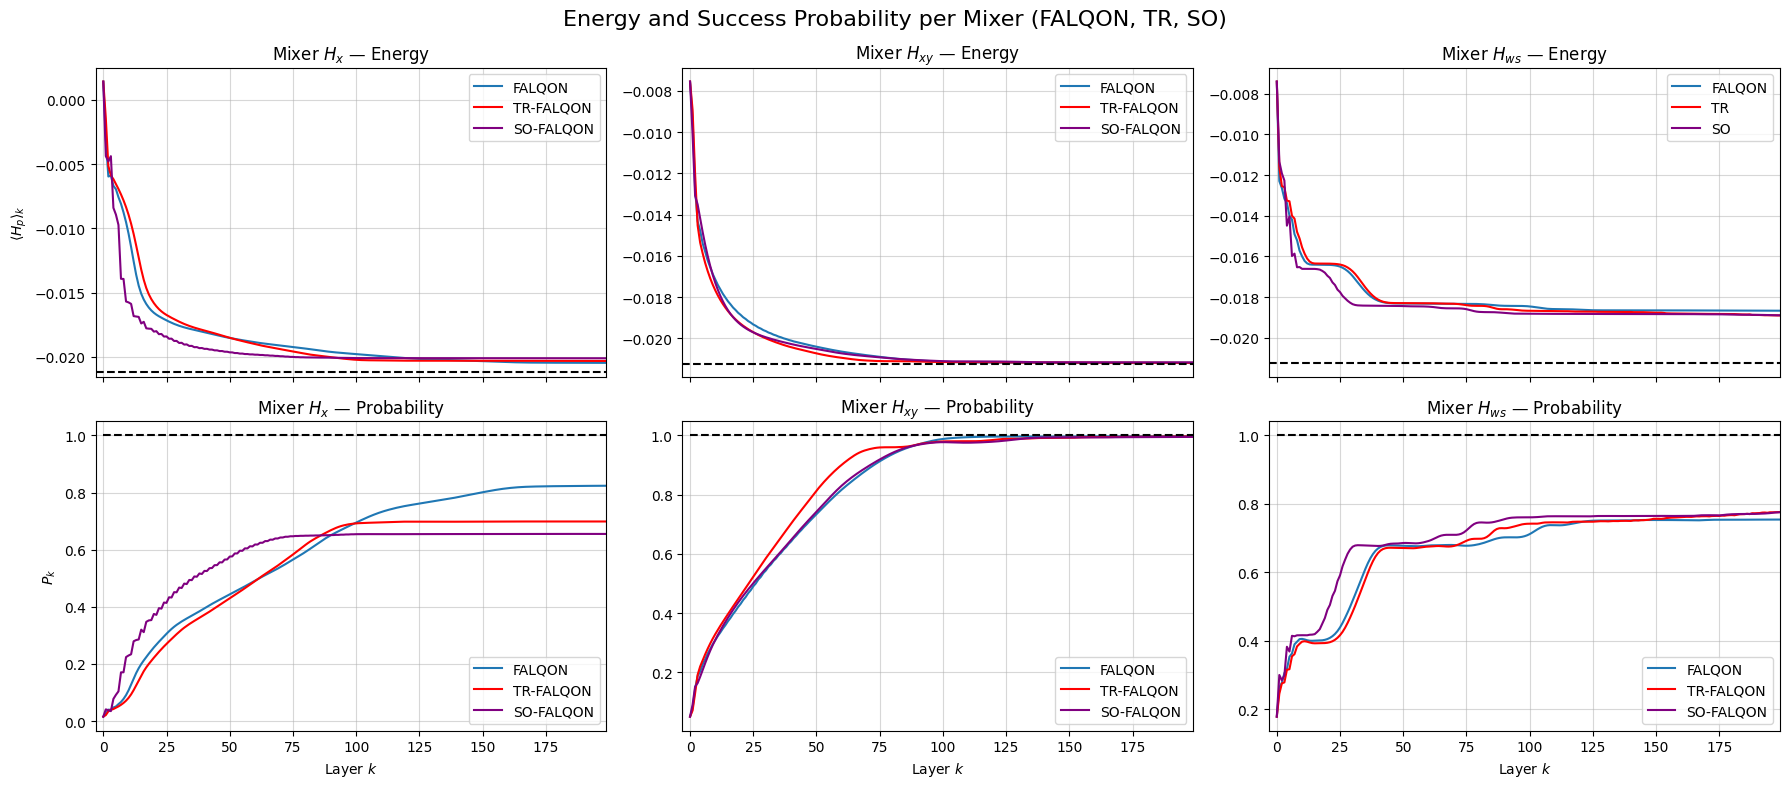

In [ ]:
#@title Gráfico (Energy & Probability)

fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharex=True)

# Column 1 — Mixer X
axs[0, 0].plot(energias_x, label="FALQON", color="C0")
axs[0, 0].plot(trenergia,  label="TR-FALQON",     color="red")
axs[0, 0].plot(soenergia,  label="SO-FALQON",     color="purple")
axs[0, 0].axhline(float(emin), ls="--", color="black")
axs[0, 0].set_ylabel(r"$\langle H_p \rangle_k$")
axs[0, 0].set_title(r"Mixer $H_x$ — Energy")
axs[0, 0].legend(fontsize=10)
axs[0, 0].grid(alpha=0.5)

axs[1, 0].plot(prob_x, label="FALQON", color="C0")
axs[1, 0].plot(trprob, label="TR-FALQON",     color="red")
axs[1, 0].plot(soprob, label="SO-FALQON",     color="purple")
axs[1, 0].plot(np.ones(len(prob_x)), "--", color="black")
axs[1, 0].set_ylabel(r"$P_k$")
axs[1, 0].set_xlabel(r"Layer $k$")
axs[1, 0].set_title(r"Mixer $H_x$ — Probability")
axs[1, 0].legend(fontsize=10)
axs[1, 0].grid(alpha=0.5)

# Column 2 — Mixer XY
axs[0, 1].plot(energias_xy,  label="FALQON", color="C0")
axs[0, 1].plot(trenergia_xy, label="TR-FALQON",     color="red")
axs[0, 1].plot(soenergia_xy, label="SO-FALQON",     color="purple")
axs[0, 1].axhline(float(emin), ls="--", color="black")
axs[0, 1].set_title(r"Mixer $H_{xy}$ — Energy")
axs[0, 1].legend(fontsize=10)
axs[0, 1].grid(alpha=0.5)

axs[1, 1].plot(prob_xy,   label="FALQON", color="C0")
axs[1, 1].plot(trprob_xy, label="TR-FALQON",     color="red")
axs[1, 1].plot(soprob_xy, label="SO-FALQON",     color="purple")
axs[1, 1].plot(np.ones(len(prob_xy)), "--", color="black")
axs[1, 1].set_xlabel(r"Layer $k$")
axs[1, 1].set_title(r"Mixer $H_{xy}$ — Probability")
axs[1, 1].legend(fontsize=10)
axs[1, 1].grid(alpha=0.5)

# Column 3 — Mixer Warm
axs[0, 2].plot(energias_warm,  label="FALQON", color="C0")
axs[0, 2].plot(trenergia_warm, label="TR",     color="red")
axs[0, 2].plot(soenergia_warm, label="SO",     color="purple")
axs[0, 2].axhline(float(emin), ls="--", color="black")
axs[0, 2].set_title(r"Mixer $H_{ws}$ — Energy")
axs[0, 2].legend(fontsize=10)
axs[0, 2].grid(alpha=0.5)

axs[1, 2].plot(prob_warm,   label="FALQON", color="C0")
axs[1, 2].plot(trprob_warm, label="TR-FALQON",     color="red")
axs[1, 2].plot(soprob_warm, label="SO-FALQON",     color="purple")
axs[1, 2].plot(np.ones(len(prob_warm)), "--", color="black")
axs[1, 2].set_xlabel(r"Layer $k$")
axs[1, 2].set_title(r"Mixer $H_{ws}$ — Probability")
axs[1, 2].legend(fontsize=10)
axs[1, 2].grid(alpha=0.5)

for i in range(2):
    for j in range(3):
        axs[i, j].set_xlim(-3, layers - 1)

fig.suptitle("Energy and Success Probability per Mixer (FALQON, TR, SO)", fontsize=16)

plt.savefig("energy_probability_3_mixers.pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()


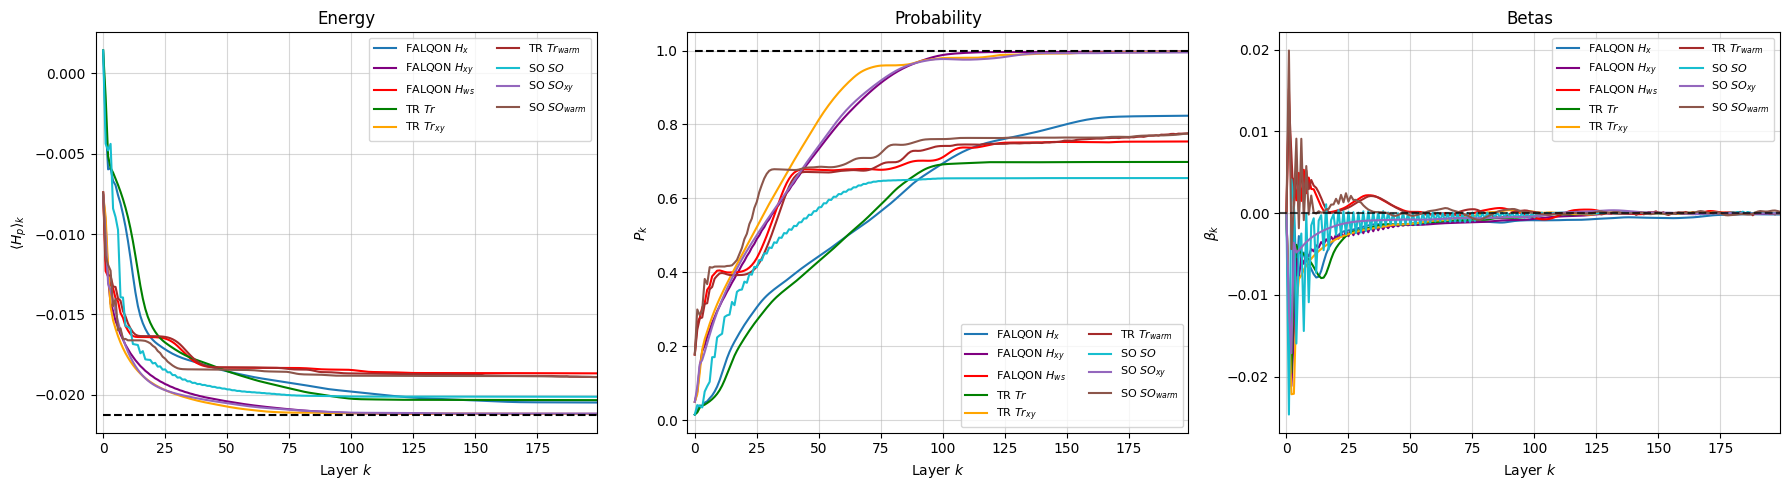

In [ ]:
#@title Gráfico

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

# ======================================================
# Coluna 1 — Energy (FALQON, TR, SO)
# ======================================================
axs[0].plot(energias_x,     label=r"FALQON $H_x$")
axs[0].plot(energias_xy,    label=r"FALQON $H_{xy}$",  color="purple")
axs[0].plot(energias_warm,  label=r"FALQON $H_{ws}$",  color="red")

axs[0].plot(trenergia,      label=r"TR $Tr$",          color="green")
axs[0].plot(trenergia_xy,   label=r"TR $Tr_{xy}$",     color="orange")
axs[0].plot(trenergia_warm, label=r"TR $Tr_{warm}$",   color="brown")

axs[0].plot(soenergia,      label=r"SO $SO$",          color="#17becf")
axs[0].plot(soenergia_xy,   label=r"SO $SO_{xy}$",     color="#9467bd")
axs[0].plot(soenergia_warm, label=r"SO $SO_{warm}$",   color="#8c564b")

axs[0].plot(np.ones(len(energias_xy)) * float(emin), "--", color="black")
axs[0].set_ylabel(r"$\langle H_p \rangle_k$")
axs[0].set_title("Energy")
axs[0].grid(alpha=0.5)
axs[0].legend(fontsize=8, ncol=2)

# ======================================================
# Coluna 2 — Probability (FALQON, TR, SO)
# ======================================================
axs[1].plot(prob_x,     label=r"FALQON $H_x$")
axs[1].plot(prob_xy,    label=r"FALQON $H_{xy}$",  color="purple")
axs[1].plot(prob_warm,  label=r"FALQON $H_{ws}$",  color="red")

axs[1].plot(trprob,     label=r"TR $Tr$",          color="green")
axs[1].plot(trprob_xy,  label=r"TR $Tr_{xy}$",     color="orange")
axs[1].plot(trprob_warm,label=r"TR $Tr_{warm}$",   color="brown")

axs[1].plot(soprob,     label=r"SO $SO$",          color="#17becf")
axs[1].plot(soprob_xy,  label=r"SO $SO_{xy}$",     color="#9467bd")
axs[1].plot(soprob_warm,label=r"SO $SO_{warm}$",   color="#8c564b")

axs[1].plot(np.ones(len(prob_xy)), "--", color="black")
axs[1].set_ylabel(r"$P_k$")
axs[1].set_title("Probability")
axs[1].grid(alpha=0.5)
axs[1].legend(fontsize=8, ncol=2)

# ======================================================
# Coluna 3 — Betas (FALQON, TR, SO)
# ======================================================
axs[2].plot(betas_x,    label=r"FALQON $H_x$")
axs[2].plot(betas_xy,   label=r"FALQON $H_{xy}$",  color="purple")
axs[2].plot(betas_warm, label=r"FALQON $H_{ws}$",  color="red")

axs[2].plot(trbeta,     label=r"TR $Tr$",          color="green")
axs[2].plot(trbeta_xy,  label=r"TR $Tr_{xy}$",     color="orange")
axs[2].plot(trbeta_warm,label=r"TR $Tr_{warm}$",   color="brown")

axs[2].plot(sobeta,     label=r"SO $SO$",          color="#17becf")
axs[2].plot(sobeta_xy,  label=r"SO $SO_{xy}$",     color="#9467bd")
axs[2].plot(sobeta_warm,label=r"SO $SO_{warm}$",   color="#8c564b")

axs[2].axhline(0.0, ls="--", color="black", alpha=0.7)
axs[2].set_ylabel(r"$\beta_k$")
axs[2].set_title("Betas")
axs[2].grid(alpha=0.5)
axs[2].legend(fontsize=8, ncol=2)

# ======================================================
# Ajustes finais
# ======================================================
for j in range(3):
    axs[j].set_xlim(-3, layers - 1)
    axs[j].set_xlabel(r"Layer $k$")

plt.tight_layout()
plt.show()


In [ ]:
#@title Multi-seed execution (FALQON, TR, SO)

seeds = [1, 2, 3, 4, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 71, 79, 83, 89, 97]

def init_dict():
    return {"x": [], "xy": [], "warm": []}

def mean_curves(d):
    return {k: np.mean(np.array(v), axis=0) for k, v in d.items()}

E_f, P_f, B_f    = init_dict(), init_dict(), init_dict()
E_tr, P_tr, B_tr = init_dict(), init_dict(), init_dict()
E_so, P_so, B_so = init_dict(), init_dict(), init_dict()

for s in seeds:

    torch.manual_seed(s)
    np.random.seed(s)

    # =========================
    # FALQON
    # =========================
    print(f"Seed {s} | FALQON")

    dt, layers, beta0 = 12, 200, 0
    Hd = qtsuru.Hx(L, device=device)
    _, E, B, P = qtsuru.falqon(Hp, Hd, psi0_x, dt, layers, beta0, psi_x, True, estados, print_interval=None)
    E_f["x"].append(E); P_f["x"].append(P); B_f["x"].append(B)

    dt, layers, beta0, alpha = 20, 200, 0, 3
    Hd = Hxy(L, alpha, device)
    _, E, B, P = qtsuru.falqon(Hp, Hd, psi0_xy, dt, layers, beta0, psi_xy, True, estados, print_interval=None)
    E_f["xy"].append(E); P_f["xy"].append(P); B_f["xy"].append(B)

    dt, layers, beta0 = 20, 200, 0
    Hd = Hwarm(L, c_stars, epsilon, device=device)
    _, E, B, P = qtsuru.falqon(Hp, Hd, psi0_warm, dt, layers, beta0, psi_warm, True, estados, print_interval=None)
    E_f["warm"].append(E); P_f["warm"].append(P); B_f["warm"].append(B)

    # =========================
    # TR-FALQON
    # =========================
    print(f"Seed {s} | TR-FALQON")

    df = qtsuru.fqas.df1

    dt, layers, beta0, a = 10, 200, 0, 8
    tf = dt * layers * a * 5
    Hd = qtsuru.Hx(L, device=device)
    _, E, B, P = qtsuru.trfalqon(Hp, Hd, psi0_x, dt, layers, df, [tf, a], beta0, psi_x, True, estados, None)
    E_tr["x"].append(E); P_tr["x"].append(P); B_tr["x"].append(B)

    dt, layers, beta0, a = 18, 200, 0, 8
    tf = dt * layers * a * 5
    Hd = Hwarm(L, c_stars, epsilon, device=device)
    _, E, B, P = qtsuru.trfalqon(Hp, Hd, psi0_warm, dt, layers, df, [tf, a], beta0, psi_x, True, estados, None)
    E_tr["warm"].append(E); P_tr["warm"].append(P); B_tr["warm"].append(B)

    dt, layers, beta0, a, alpha = 20, 200, 0, 10, 4
    tf = dt * layers * a * 5
    Hd = Hxy(L, alpha, device)
    _, E, B, P = qtsuru.trfalqon(Hp, Hd, psi0_xy, dt, layers, df, [tf, a], beta0, psi_x, True, estados, None)
    E_tr["xy"].append(E); P_tr["xy"].append(P); B_tr["xy"].append(B)

    # =========================
    # SO-FALQON
    # =========================
    print(f"Seed {s} | SO-FALQON")

    dt, layers, beta0 = 20, 200, 0
    Hd = qtsuru.Hx(L, device=device)
    _, E, B, P = qtsuru.sofalqon(Hp, Hd, psi0_x, dt, layers, beta0, True, psi_x, True, estados, None)
    E_so["x"].append(E); P_so["x"].append(P); B_so["x"].append(B)

    dt, layers, beta0 = 27, 200, 0
    Hd = Hwarm(L, c_stars, epsilon, device=device)
    _, E, B, P = qtsuru.sofalqon(Hp, Hd, psi0_warm, dt, layers, beta0, True, psi_x, True, estados, None)
    E_so["warm"].append(E); P_so["warm"].append(P); B_so["warm"].append(B)

    dt, layers, beta0, alpha = 20, 200, 0, 2
    Hd = Hxy(L, alpha, device)
    _, E, B, P = qtsuru.sofalqon(Hp, Hd, psi0_xy, dt, layers, beta0, True, psi_x, True, estados, None)
    E_so["xy"].append(E); P_so["xy"].append(P); B_so["xy"].append(B)

# Means
E_f_m,  P_f_m,  B_f_m  = mean_curves(E_f),  mean_curves(P_f),  mean_curves(B_f)
E_tr_m, P_tr_m, B_tr_m = mean_curves(E_tr), mean_curves(P_tr), mean_curves(B_tr)
E_so_m, P_so_m, B_so_m = mean_curves(E_so), mean_curves(P_so), mean_curves(B_so)


Seed 1 | FALQON
Seed 1 | TR-FALQON
Seed 1 | SO-FALQON
Seed 2 | FALQON
Seed 2 | TR-FALQON
Seed 2 | SO-FALQON
Seed 3 | FALQON
Seed 3 | TR-FALQON
Seed 3 | SO-FALQON
Seed 4 | FALQON
Seed 4 | TR-FALQON
Seed 4 | SO-FALQON
Seed 5 | FALQON
Seed 5 | TR-FALQON
Seed 5 | SO-FALQON
Seed 7 | FALQON
Seed 7 | TR-FALQON
Seed 7 | SO-FALQON
Seed 11 | FALQON
Seed 11 | TR-FALQON
Seed 11 | SO-FALQON
Seed 13 | FALQON
Seed 13 | TR-FALQON
Seed 13 | SO-FALQON
Seed 17 | FALQON
Seed 17 | TR-FALQON
Seed 17 | SO-FALQON
Seed 19 | FALQON
Seed 19 | TR-FALQON
Seed 19 | SO-FALQON
Seed 23 | FALQON
Seed 23 | TR-FALQON
Seed 23 | SO-FALQON
Seed 29 | FALQON
Seed 29 | TR-FALQON
Seed 29 | SO-FALQON
Seed 31 | FALQON
Seed 31 | TR-FALQON
Seed 31 | SO-FALQON
Seed 37 | FALQON
Seed 37 | TR-FALQON
Seed 37 | SO-FALQON
Seed 41 | FALQON
Seed 41 | TR-FALQON
Seed 41 | SO-FALQON
Seed 43 | FALQON
Seed 43 | TR-FALQON
Seed 43 | SO-FALQON
Seed 47 | FALQON
Seed 47 | TR-FALQON
Seed 47 | SO-FALQON
Seed 53 | FALQON
Seed 53 | TR-FALQON
Seed 53 | SO

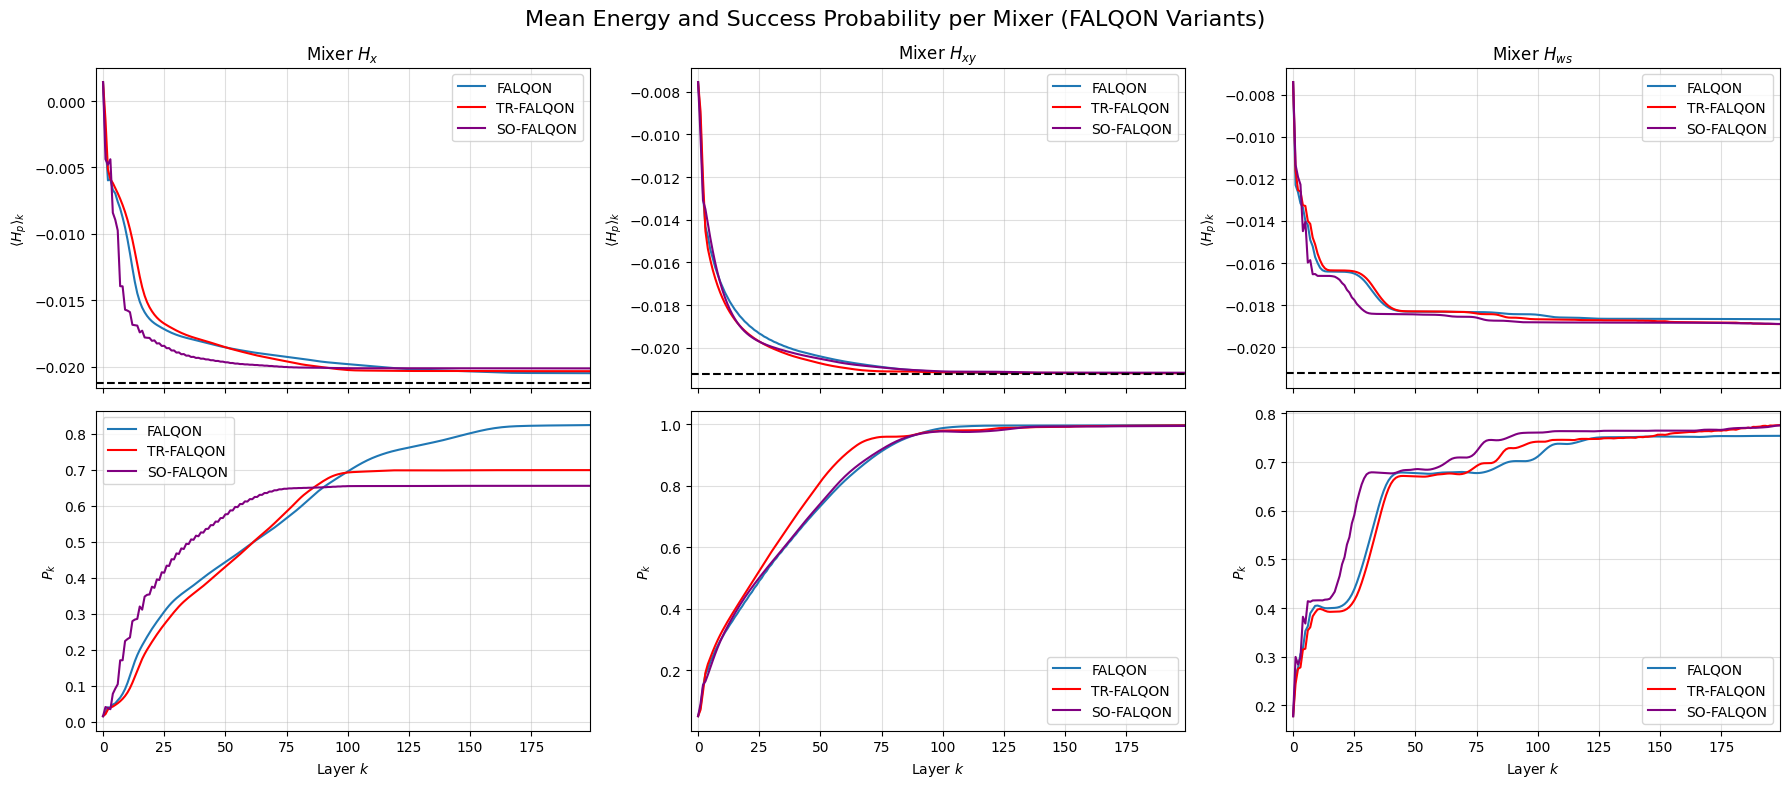

In [ ]:
#@title Mean Energy and Probability

fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharex=True)

def plot_mixer_column(axE, axP, E, P, title):
    axE.plot(E["falqon"], label="FALQON",    color="C0")   # Blue
    axE.plot(E["tr"],     label="TR-FALQON", color="red")
    axE.plot(E["so"],     label="SO-FALQON", color="purple")
    axE.axhline(float(emin), ls="--", c="k")
    axE.set_ylabel(r"$\langle H_p \rangle_k$")
    axE.set_title(title)
    axE.legend(fontsize=10)
    axE.grid(alpha=0.4)

    axP.plot(P["falqon"], label="FALQON",    color="C0")   # Blue
    axP.plot(P["tr"],     label="TR-FALQON", color="red")
    axP.plot(P["so"],     label="SO-FALQON", color="purple")
    axP.set_ylabel(r"$P_k$")
    axP.set_xlabel("Layer $k$")
    axP.legend(fontsize=10)
    axP.grid(alpha=0.4)

plot_mixer_column(
    axs[0, 0], axs[1, 0],
    {"falqon": E_f_m["x"],  "tr": E_tr_m["x"],  "so": E_so_m["x"]},
    {"falqon": P_f_m["x"],  "tr": P_tr_m["x"],  "so": P_so_m["x"]},
    r"Mixer $H_x$"
)

plot_mixer_column(
    axs[0, 1], axs[1, 1],
    {"falqon": E_f_m["xy"], "tr": E_tr_m["xy"], "so": E_so_m["xy"]},
    {"falqon": P_f_m["xy"], "tr": P_tr_m["xy"], "so": P_so_m["xy"]},
    r"Mixer $H_{xy}$"
)

plot_mixer_column(
    axs[0, 2], axs[1, 2],
    {"falqon": E_f_m["warm"], "tr": E_tr_m["warm"], "so": E_so_m["warm"]},
    {"falqon": P_f_m["warm"], "tr": P_tr_m["warm"], "so": P_so_m["warm"]},
    r"Mixer $H_{ws}$"
)

for i in range(2):
    for j in range(3):
        axs[i, j].set_xlim(-3, layers - 1)

fig.suptitle("Mean Energy and Success Probability per Mixer (FALQON Variants)", fontsize=16)

plt.savefig("mean_energy_probability_mixers.pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()


In [ ]:
#@title csv

import pandas as pd
import numpy as np

def to_1d(x):
    return np.asarray(x).reshape(-1)

layers_range = np.arange(layers)

data = {
    "layer": layers_range,

    # Energy — Hx
    "E_falqon_x":   to_1d(E_f_m["x"]),
    "E_tr_x":       to_1d(E_tr_m["x"]),
    "E_so_x":       to_1d(E_so_m["x"]),

    # Probability — Hx
    "P_falqon_x":   to_1d(P_f_m["x"]),
    "P_tr_x":       to_1d(P_tr_m["x"]),
    "P_so_x":       to_1d(P_so_m["x"]),

    # Energy — Hxy
    "E_falqon_xy":  to_1d(E_f_m["xy"]),
    "E_tr_xy":      to_1d(E_tr_m["xy"]),
    "E_so_xy":      to_1d(E_so_m["xy"]),

    # Probability — Hxy
    "P_falqon_xy":  to_1d(P_f_m["xy"]),
    "P_tr_xy":      to_1d(P_tr_m["xy"]),
    "P_so_xy":      to_1d(P_so_m["xy"]),

    # Energy — Hws
    "E_falqon_warm": to_1d(E_f_m["warm"]),
    "E_tr_warm":     to_1d(E_tr_m["warm"]),
    "E_so_warm":     to_1d(E_so_m["warm"]),

    # Probability — Hws
    "P_falqon_warm": to_1d(P_f_m["warm"]),
    "P_tr_warm":     to_1d(P_tr_m["warm"]),
    "P_so_warm":     to_1d(P_so_m["warm"]),
}

df = pd.DataFrame(data)
df.to_csv("mean_energy_probability_mixers.csv", index=False)

In [ ]:
df

,layer,E_falqon_x,E_tr_x,E_so_x,P_falqon_x,P_tr_x,P_so_x,E_falqon_xy,E_tr_xy,E_so_xy,P_falqon_xy,P_tr_xy,P_so_xy,E_falqon_warm,E_tr_warm,E_so_warm,P_falqon_warm,P_tr_warm,P_so_warm
0,0,0.001425,0.001425,0.001425,0.015625,0.015625,0.015625,-0.007546,-0.007546,-0.007546,0.050000,0.050000,0.050000,-0.007410,-0.007410,-0.007410,0.177979,0.177979,0.177979
1,1,-0.003030,-0.001431,-0.004379,0.025560,0.021234,0.041119,-0.009337,-0.008914,-0.010093,0.077649,0.070763,0.090168,-0.012295,-0.011603,-0.011339,0.263605,0.244835,0.299790
2,2,-0.005968,-0.005145,-0.004791,0.040151,0.034080,0.038207,-0.012759,-0.012036,-0.013084,0.144549,0.129054,0.151523,-0.012639,-0.012540,-0.011915,0.277118,0.275304,0.284242
3,3,-0.005896,-0.005880,-0.004381,0.039413,0.039394,0.034912,-0.014324,-0.014521,-0.013506,0.186875,0.191372,0.163345,-0.013162,-0.012600,-0.012273,0.305345,0.278168,0.298759
4,4,-0.006689,-0.006168,-0.008406,0.047858,0.042323,0.077787,-0.014777,-0.015360,-0.014188,0.202589,0.219542,0.184689,-0.013366,-0.013256,-0.014485,0.317258,0.314862,0.382264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,195,-0.020476,-0.020329,-0.020119,0.823566,0.698629,0.655100,-0.021187,-0.021190,-0.021168,0.997663,0.996426,0.994759,-0.018661,-0.018887,-0.018877,0.753689,0.775279,0.772849
196,196,-0.020476,-0.020329,-0.020119,0.823628,0.698619,0.655104,-0.021187,-0.021190,-0.021168,0.997674,0.996446,0.994777,-0.018661,-0.018886,-0.018881,0.753733,0.775148,0.773722
197,197,-0.020477,-0.020329,-0.020119,0.823677,0.698641,0.655107,-0.021187,-0.021190,-0.021168,0.997685,0.996447,0.994795,-0.018662,-0.018893,-0.018885,0.753827,0.775591,0.774540
198,198,-0.020477,-0.020329,-0.020119,0.823709,0.698665,0.655104,-0.021187,-0.021190,-0.021168,0.997697,0.996425,0.994815,-0.018662,-0.018895,-0.018888,0.753936,0.775765,0.775064


In [ ]:
P_f_m['x'][25]

array([0.30564496])

In [ ]:
import numpy as np

layers_sel = [25, 50, 75, 100]

def pct(x):
    x = float(x)
    return f"{100*x:.2f}%"

print(f"{'Mixer':<6} {'Variant':<10} "
      f"{'k=25':>8} {'k=50':>8} {'k=75':>8} {'k=100':>8}")

# Hx
print(f"{'H_x':<6} {'FALQON':<10} "
      f"{pct(P_f_m['x'][25]):>8} {pct(P_f_m['x'][50]):>8} "
      f"{pct(P_f_m['x'][75]):>8} {pct(P_f_m['x'][100]):>8}")

print(f"{'H_x':<6} {'TR-FALQON':<10} "
      f"{pct(P_tr_m['x'][25]):>8} {pct(P_tr_m['x'][50]):>8} "
      f"{pct(P_tr_m['x'][75]):>8} {pct(P_tr_m['x'][100]):>8}")

print(f"{'H_x':<6} {'SO-FALQON':<10} "
      f"{pct(P_so_m['x'][25]):>8} {pct(P_so_m['x'][50]):>8} "
      f"{pct(P_so_m['x'][75]):>8} {pct(P_so_m['x'][100]):>8}")

# Hxy
print(f"{'H_xy':<6} {'FALQON':<10} "
      f"{pct(P_f_m['xy'][25]):>8} {pct(P_f_m['xy'][50]):>8} "
      f"{pct(P_f_m['xy'][75]):>8} {pct(P_f_m['xy'][100]):>8}")

print(f"{'H_xy':<6} {'TR-FALQON':<10} "
      f"{pct(P_tr_m['xy'][25]):>8} {pct(P_tr_m['xy'][50]):>8} "
      f"{pct(P_tr_m['xy'][75]):>8} {pct(P_tr_m['xy'][100]):>8}")

print(f"{'H_xy':<6} {'SO-FALQON':<10} "
      f"{pct(P_so_m['xy'][25]):>8} {pct(P_so_m['xy'][50]):>8} "
      f"{pct(P_so_m['xy'][75]):>8} {pct(P_so_m['xy'][100]):>8}")

# Hws
print(f"{'H_ws':<6} {'FALQON':<10} "
      f"{pct(P_f_m['warm'][25]):>8} {pct(P_f_m['warm'][50]):>8} "
      f"{pct(P_f_m['warm'][75]):>8} {pct(P_f_m['warm'][100]):>8}")

print(f"{'H_ws':<6} {'TR-FALQON':<10} "
      f"{pct(P_tr_m['warm'][25]):>8} {pct(P_tr_m['warm'][50]):>8} "
      f"{pct(P_tr_m['warm'][75]):>8} {pct(P_tr_m['warm'][100]):>8}")

print(f"{'H_ws':<6} {'SO-FALQON':<10} "
      f"{pct(P_so_m['warm'][25]):>8} {pct(P_so_m['warm'][50]):>8} "
      f"{pct(P_so_m['warm'][75]):>8} {pct(P_so_m['warm'][100]):>8}")


Mixer  Variant        k=25     k=50     k=75    k=100
H_x    FALQON       30.56%   44.32%   56.52%   69.49%
H_x    TR-FALQON    27.03%   43.02%   58.31%   69.21%
H_x    SO-FALQON    41.39%   57.60%   64.69%   65.42%
H_xy   FALQON       49.03%   73.37%   91.24%   98.80%
H_xy   TR-FALQON    52.28%   81.31%   95.93%   97.97%
H_xy   SO-FALQON    50.08%   74.23%   91.87%   97.71%
H_ws   FALQON       43.88%   67.75%   67.75%   71.15%
H_ws   TR-FALQON    41.60%   67.08%   69.21%   74.20%
H_ws   SO-FALQON    59.10%   68.55%   72.24%   76.05%


/tmp/ipykernel_644/907629440.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x = float(x)


---

In [ ]:
#@title Parâmetros do Problema
n_assets = 10
num_qubits = n_assets
B = n_assets // 2
eta = n_assets * 0.001
lam = 2
seed = 3


In [ ]:
#@title 10 Ativos

#Geração de Dados Financeiros Aleatórios com Qiskit Finance
stocks = [("TICKER%s" % i) for i in range(n_assets)]
data = RandomDataProvider(
    tickers=stocks,
    start=datetime.datetime(2016, 1, 1),
    end=datetime.datetime(2016, 1, 30),
    seed=seed,
)
data.run()
mu = data.get_period_return_mean_vector()
Sigma = data.get_period_return_covariance_matrix()

print("Média da matriz de covariância Σ:", np.mean(Sigma))
print("Média dos retornos μ:", np.mean(mu))

#Resolução Clássica com Solver Exato
portfolio = PortfolioOptimization(
    expected_returns=mu,
    covariances=Sigma,
    risk_factor=lam,
    budget=B
)

qp = portfolio.to_quadratic_program()
def print_result(result):
    selection = result.x
    value = result.fval
    print("\nOptimal: selection {}, value {:.4f}".format(selection, value))
    eigenstate = result.min_eigen_solver_result.eigenstate
    probabilities = (
        eigenstate.binary_probabilities()
        if isinstance(eigenstate, QuasiDistribution)
        else {k: np.abs(v) ** 2 for k, v in eigenstate.to_dict().items()}
    )

    print("\n----------------- Full result ---------------------")
    print("selection\tvalue\t\tprobability")
    print("---------------------------------------------------")

    probabilities = sorted(probabilities.items(), key=lambda x: x[1], reverse=True)

    for k, v in probabilities:
        x = np.array([int(i) for i in list(reversed(k))])
        value = portfolio.to_quadratic_program().objective.evaluate(x)
        print("%10s\t%.4f\t\t%.4f" % (x, value, v))

exact_mes = NumPyMinimumEigensolver()
exact_eigensolver = MinimumEigenOptimizer(exact_mes)
result = exact_eigensolver.solve(qp)
print_result(result)

#Exact Classical Solution
min_cost = float("inf")
min_asset = -1

for asset in range(2**n_assets):
    a = cost_function(asset, Sigma, mu, lam, eta, B)
    if a <= min_cost:
        min_cost = a
        min_asset = asset

print(f"\nMelhor carteira: {np.binary_repr(int(min_asset), n_assets)[::-1]} <-> {int(np.binary_repr(int(min_asset), n_assets), 2)}, custo: {min_cost}")

#Hamiltonian Ground State
Hp = Hportifolio(n_assets, Sigma, mu, 1, lam, eta, B, device)
diag_Hp = Hp.diag_hamiltonian.real

vals = torch.sort(torch.unique(diag_Hp)).values
E0 = float(vals[0])
E1 = float(vals[1]) if len(vals) > 1 else None
E2 = float(vals[2]) if len(vals) > 2 else None

print(f"\nE0 (fundamental): {E0}")
if E1 is not None: print(f"E1 (1º excitado): {E1}")
if E2 is not None: print(f"E2 (2º excitado): {E2}")

emin = torch.min(diag_Hp)
estados = torch.argwhere(diag_Hp == emin)
idx0 = int(estados[0].item())

print(f"\nEstado: {np.binary_repr(idx0, n_assets)[::-1]} <-> {idx0}, Energia: {E0}")

#Warm-Starting
mdl = create_continuous_portfolio_problem(mu, Sigma, lam, B)
qp_relaxed = from_docplex_mp(mdl)
result = CplexOptimizer().solve(qp_relaxed)
c_stars = result.x

print("\nRelaxed solution x:", np.round(c_stars, 2))

epsilon = 0.25
L = num_qubits

st = qtsuru.States(L, device=device)

psi0_xy = st.hamming_weight_state(B)
psi0_x = st.uniform_superposition()
psi0_warm = warm_starting(L, c_stars, epsilon = epsilon, device = device, out = None)
psi_xy = torch.clone(psi0_xy)
psi_x = torch.clone(psi0_x)
psi_warm = torch.clone(psi0_warm)

probabilidade = torch.clone(psi0_xy)

Média da matriz de covariância Σ: 0.0016117732638738624
Média dos retornos μ: -0.0011266084178487338

Optimal: selection [0. 0. 0. 1. 1. 1. 1. 0. 0. 1.], value -0.0101

----------------- Full result ---------------------
selection	value		probability
---------------------------------------------------
[0 0 0 1 1 1 1 0 0 1]	-0.0101		1.0000

Melhor carteira: 0001111001 <-> 632, custo: -0.010091310458088242

E0 (fundamental): -0.010091310458088242
E1 (1º excitado): -0.00810109933619118
E2 (2º excitado): -0.0068625155867741835

Estado: 0001111001 <-> 632, Energia: -0.010091310458088242

Relaxed solution x: [0.31 0.   0.   0.89 0.61 1.   1.   0.   0.2  1.  ]


Running FALQON with Hx...
Layer 100, E = 0.004951297538096134
Layer 200, E = -0.00028587866234290637
Layer 300, E = -0.002466386214094478
Layer 400, E = -0.0035079291665673085
Layer 500, E = -0.004417137862630547
Running FALQON with Hxy...
Layer 100, E = -0.003969171841141454
Layer 200, E = -0.005432608096945405
Layer 300, E = -0.006207150118623108
Layer 400, E = -0.0064688198241257345
Layer 500, E = -0.0064967492467147715
Running FALQON with Hws...
Layer 100, E = 0.020863107430198192
Layer 200, E = 0.01675955583093556
Layer 300, E = 0.015828896608129306
Layer 400, E = 0.01532478126424362
Layer 500, E = 0.014855784163864896
Running TR-FALQON with Hx...
Layer 100, E = 0.005477758084123694
Layer 200, E = -0.0008497688914274658
Layer 300, E = -0.004375923698750087
Layer 400, E = -0.006318115855604206
Layer 500, E = -0.006654432342983496
Running TR-FALQON with Hxy...
Layer 100, E = -0.003989059291927292
Layer 200, E = -0.005478396901563643
Layer 300, E = -0.006277301968820459
Layer 400, E 

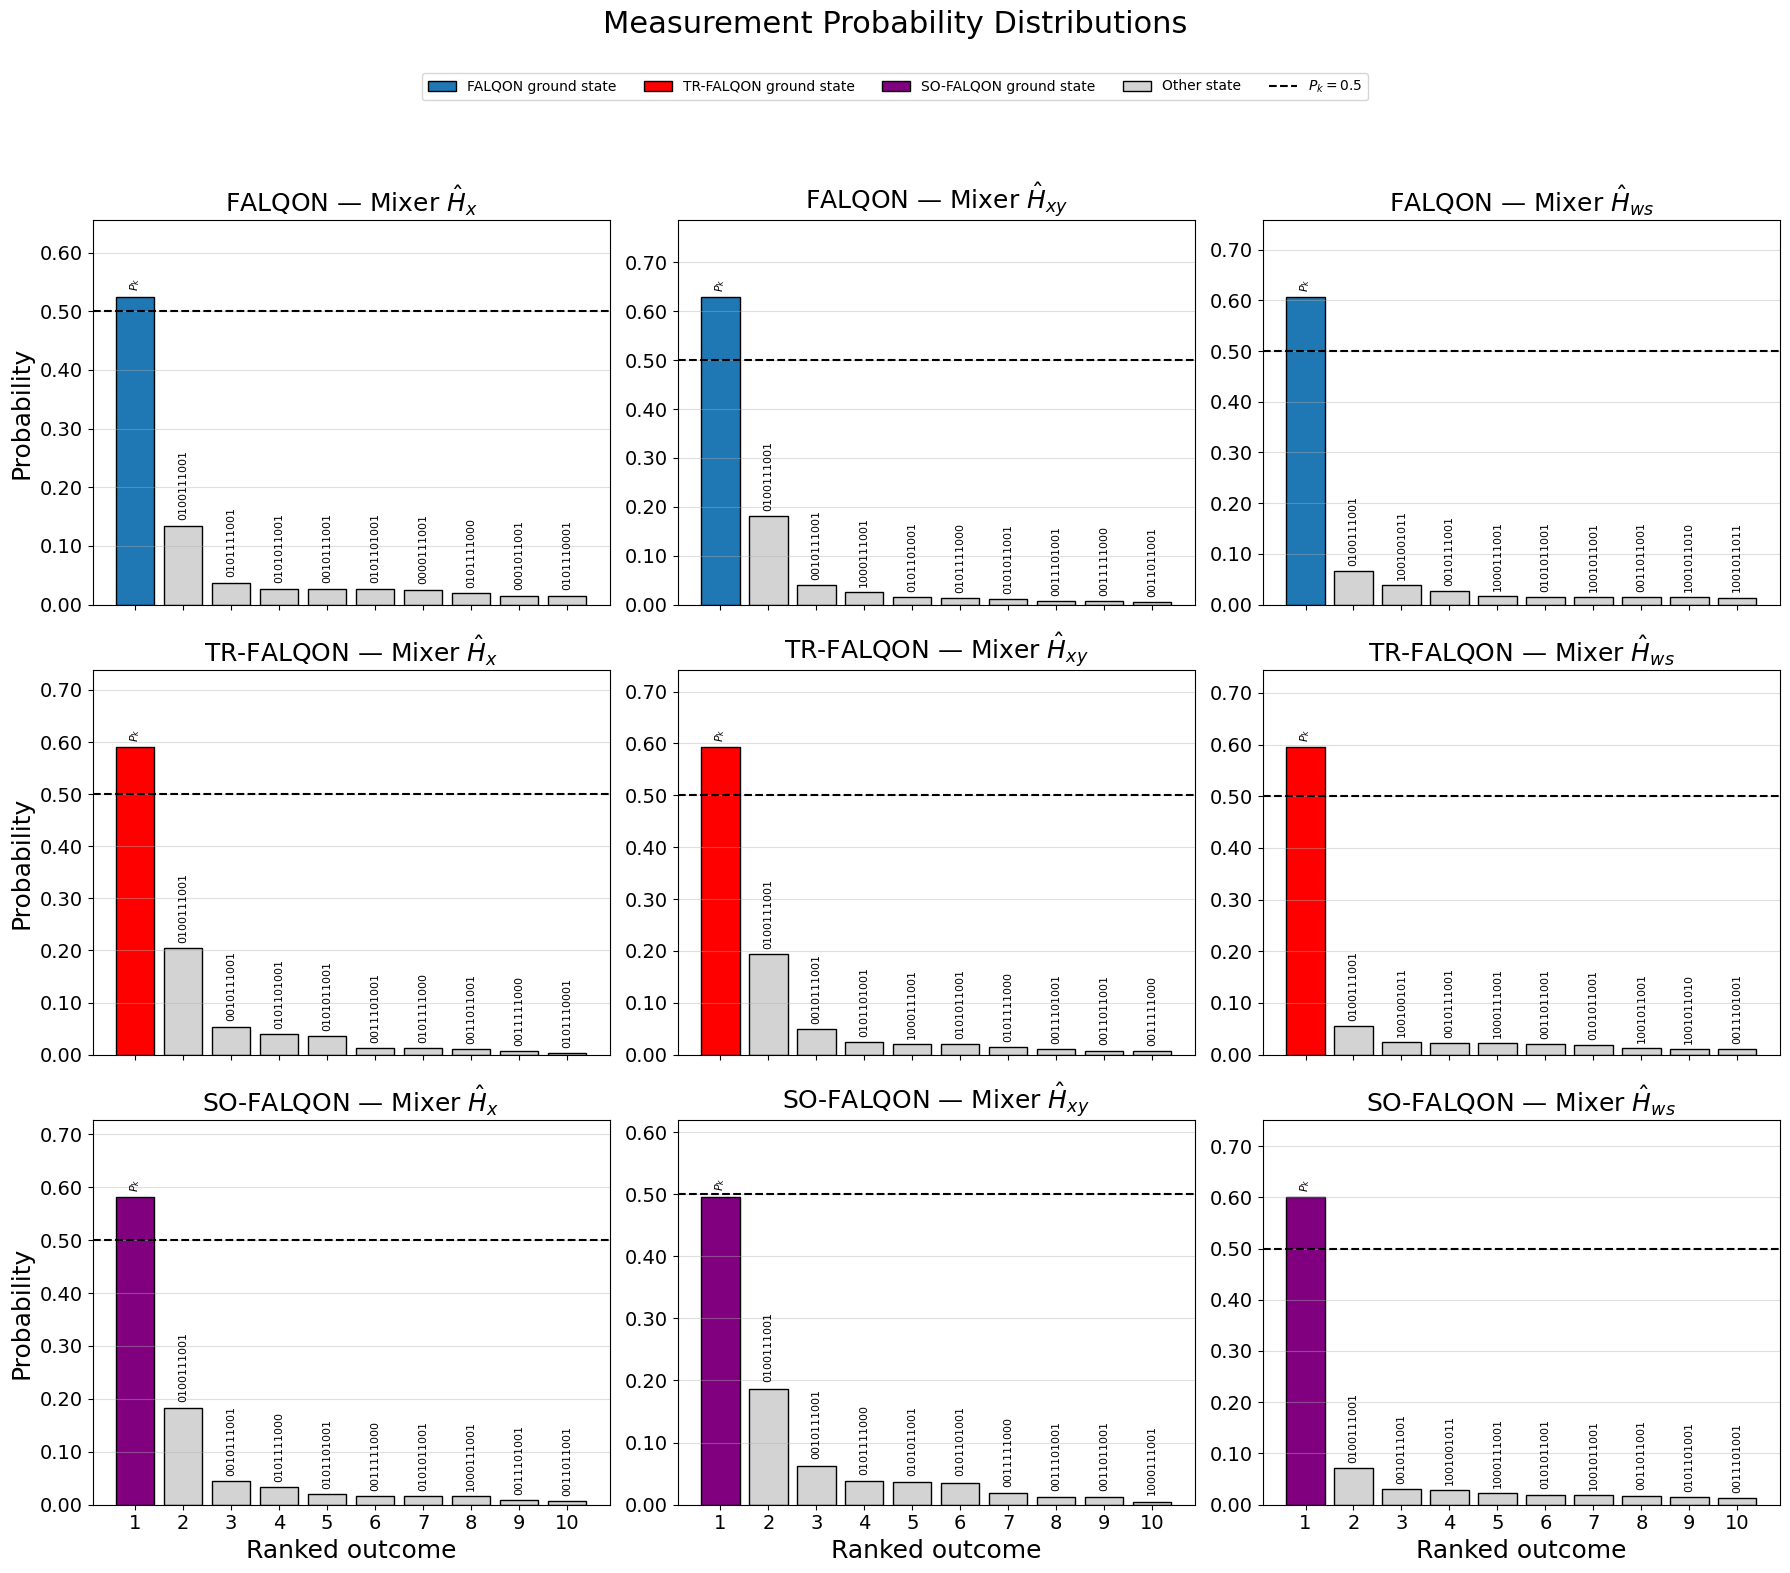

FALQON + Hx: P_k = 0.524016
FALQON + Hxy: P_k = 0.628756
FALQON + Hws: P_k = 0.606394
TR-FALQON + Hx: P_k = 0.590000
TR-FALQON + Hxy: P_k = 0.592706
TR-FALQON + Hws: P_k = 0.594856
SO-FALQON + Hx: P_k = 0.580852
SO-FALQON + Hxy: P_k = 0.494861
SO-FALQON + Hws: P_k = 0.599886


In [ ]:
#@title Measurement Probability Distributions — All Configurations

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ======================================================
# General parameters
# ======================================================
hist_layers = 500
hist_beta0 = 0

algorithm_colors = {
    "FALQON": "C0",
    "TR-FALQON": "red",
    "SO-FALQON": "purple",
}

# ======================================================
# Exact configurations used in the n=10 experiment
# ======================================================
configurations = [
    # --------------------------------------------------
    # FALQON
    # --------------------------------------------------
    {
        "algorithm": "FALQON",
        "mixer": "Hx",
        "mixer_title": r"Mixer $\hat H_x$",
        "dt": 1.8,
        "alpha": None,
        "a": None,
        "initial_state": psi0_x,
    },
    {
        "algorithm": "FALQON",
        "mixer": "Hxy",
        "mixer_title": r"Mixer $\hat H_{xy}$",
        "dt": 3.0,
        "alpha": 20,
        "a": None,
        "initial_state": psi0_xy,
    },
    {
        "algorithm": "FALQON",
        "mixer": "Hws",
        "mixer_title": r"Mixer $\hat H_{ws}$",
        "dt": 4.0,
        "alpha": None,
        "a": None,
        "initial_state": psi0_warm,
    },

    # --------------------------------------------------
    # TR-FALQON
    # --------------------------------------------------
    {
        "algorithm": "TR-FALQON",
        "mixer": "Hx",
        "mixer_title": r"Mixer $\hat H_x$",
        "dt": 1.5,
        "alpha": None,
        "a": 6,
        "initial_state": psi0_x,
    },
    {
        "algorithm": "TR-FALQON",
        "mixer": "Hxy",
        "mixer_title": r"Mixer $\hat H_{xy}$",
        "dt": 3.0,
        "alpha": 20,
        "a": 2,
        "initial_state": psi0_xy,
    },
    {
        "algorithm": "TR-FALQON",
        "mixer": "Hws",
        "mixer_title": r"Mixer $\hat H_{ws}$",
        "dt": 5.0,
        "alpha": None,
        "a": 1,
        "initial_state": psi0_warm,
    },

    # --------------------------------------------------
    # SO-FALQON
    # --------------------------------------------------
    {
        "algorithm": "SO-FALQON",
        "mixer": "Hx",
        "mixer_title": r"Mixer $\hat H_x$",
        "dt": 3.0,
        "alpha": None,
        "a": None,
        "initial_state": psi0_x,
    },
    {
        "algorithm": "SO-FALQON",
        "mixer": "Hxy",
        "mixer_title": r"Mixer $\hat H_{xy}$",
        "dt": 1.4,
        "alpha": 3,
        "a": None,
        "initial_state": psi0_xy,
    },
    {
        "algorithm": "SO-FALQON",
        "mixer": "Hws",
        "mixer_title": r"Mixer $\hat H_{ws}$",
        "dt": 5.0,
        "alpha": None,
        "a": None,
        "initial_state": psi0_warm,
    },
]

# ======================================================
# Driver construction
# ======================================================
def build_driver(configuration):

    mixer = configuration["mixer"]

    if mixer == "Hx":
        return qtsuru.Hx(
            L,
            device=device
        )

    if mixer == "Hxy":
        return Hxy(
            L,
            configuration["alpha"],
            device
        )

    if mixer == "Hws":
        return Hwarm(
            L,
            c_stars,
            epsilon,
            device=device
        )

    raise ValueError(
        f"Unknown mixer: {mixer}"
    )

# ======================================================
# Execute one configuration
# ======================================================
def run_configuration(configuration):

    driver = build_driver(
        configuration
    )

    initial_state = torch.clone(
        configuration["initial_state"]
    )

    working_state = torch.clone(
        configuration["initial_state"]
    )

    algorithm = configuration["algorithm"]
    dt = configuration["dt"]

    if algorithm == "FALQON":

        psi_final, _, _, _ = qtsuru.falqon(
            Hp,
            driver,
            initial_state,
            dt,
            hist_layers,
            hist_beta0,
            working_state,
            True,
            estados,
            print_interval=100
        )

    elif algorithm == "TR-FALQON":

        a = configuration["a"]

        tf = (
            dt
            * hist_layers
            * a
            * 5
        )

        args = [
            tf,
            a
        ]

        df = qtsuru.fqas.df1

        psi_final, _, _, _ = qtsuru.trfalqon(
            Hp,
            driver,
            initial_state,
            dt,
            hist_layers,
            df,
            args,
            hist_beta0,
            working_state,
            True,
            estados,
            100
        )

    elif algorithm == "SO-FALQON":

        psi_final, _, _, _ = qtsuru.sofalqon(
            Hp,
            driver,
            initial_state,
            dt,
            hist_layers,
            hist_beta0,
            True,
            working_state,
            True,
            estados,
            100
        )

    else:
        raise ValueError(
            f"Unknown algorithm: {algorithm}"
        )

    probabilities = (
        torch.abs(
            psi_final.detach()
        ) ** 2
    ).real.cpu().numpy().reshape(-1)

    energies = (
        diag_Hp.detach()
        .cpu()
        .numpy()
        .reshape(-1)
    )

    ground_indices = {
        int(index)
        for index in (
            estados.detach()
            .cpu()
            .reshape(-1)
            .tolist()
        )
    }

    basis_indices = np.arange(
        2**L
    )

    distribution_df = pd.DataFrame(
        {
            "algorithm": algorithm,
            "mixer": configuration["mixer"],
            "layer": hist_layers,
            "dt": dt,
            "alpha": configuration["alpha"],
            "a": configuration["a"],
            "basis_index": basis_indices,
            "bitstring": [
                np.binary_repr(
                    index,
                    width=L
                )[::-1]
                for index in basis_indices
            ],
            "probability": probabilities,
            "energy": energies,
            "is_ground_state": [
                index in ground_indices
                for index in basis_indices
            ],
        }
    )

    distribution_df = (
        distribution_df
        .sort_values(
            "probability",
            ascending=False
        )
        .reset_index(drop=True)
    )

    distribution_df.insert(
        7,
        "probability_rank",
        np.arange(
            1,
            len(distribution_df) + 1
        )
    )

    total_probability = (
        distribution_df[
            "probability"
        ].sum()
    )

    if not np.isclose(
        total_probability,
        1.0,
        atol=1e-8
    ):
        print(
            f"Warning: probabilities for "
            f"{algorithm} + "
            f"{configuration['mixer']} "
            f"sum to {total_probability:.10f}."
        )

    return distribution_df

# ======================================================
# Execute all nine configurations
# ======================================================
distribution_results = []

for configuration in configurations:

    print(
        f"Running {configuration['algorithm']} "
        f"with {configuration['mixer']}..."
    )

    distribution_df = run_configuration(
        configuration
    )

    distribution_results.append(
        {
            "configuration": configuration,
            "distribution": distribution_df,
        }
    )

# ======================================================
# Complete dataset
# ======================================================
complete_distribution_df = pd.concat(
    [
        result["distribution"]
        for result in distribution_results
    ],
    ignore_index=True
)

# CSV export intentionally disabled
# complete_distribution_df.to_csv(
#     "measurement_probabilities_all_configurations_n10_k500.csv",
#     index=False
# )

# ======================================================
# Prepare the data shown in each panel
#
# First bar:
# total ground-state probability P_k
#
# Remaining bars:
# nine most probable non-ground states
# ======================================================
def prepare_plot_distribution(
    distribution_df,
    number_of_non_ground_states=9
):

    ground_probability = (
        distribution_df.loc[
            distribution_df[
                "is_ground_state"
            ],
            "probability"
        ].sum()
    )

    non_ground_df = (
        distribution_df.loc[
            ~distribution_df[
                "is_ground_state"
            ],
            [
                "bitstring",
                "probability"
            ]
        ]
        .head(
            number_of_non_ground_states
        )
        .copy()
    )

    ground_df = pd.DataFrame(
        {
            "bitstring": [r"$P_k$"],
            "probability": [
                ground_probability
            ],
            "is_ground_state": [True],
        }
    )

    # ground_bitstring = (
    # distribution_df.loc[
    #     distribution_df["is_ground_state"],
    #     "bitstring"
    # ].iloc[0]
    # )

    # ground_df = pd.DataFrame(
    #     {
    #         "bitstring": [ground_bitstring],
    #         "probability": [ground_probability],
    #         "is_ground_state": [True],
    #     }
    # )

    non_ground_df[
        "is_ground_state"
    ] = False

    plot_df = pd.concat(
        [
            ground_df,
            non_ground_df
        ],
        ignore_index=True
    )

    plot_df[
        "plot_position"
    ] = np.arange(
        1,
        len(plot_df) + 1
    )

    return plot_df

plot_results = [
    prepare_plot_distribution(
        result["distribution"]
    )
    for result in distribution_results
]

# ======================================================
# Plot configuration
# ======================================================
fig, axs = plt.subplots(
    3,
    3,
    figsize=(18, 16),
    sharex=True
)

TITLE_SIZE    = 18
SUPTITLE_SIZE = 22
XLABEL_SIZE   = 18
YLABEL_SIZE   = 18
LEGEND_SIZE   = 10
TICK_SIZE     = 14

OTHER_COLOR = "lightgray"
REFERENCE_COLOR = "black"

# ======================================================
# Plot one panel
# ======================================================
def plot_distribution(
    ax,
    plot_df,
    algorithm,
    mixer_title,
    show_ylabel=False,
    show_xlabel=False
):

    positions = (
        plot_df[
            "plot_position"
        ].to_numpy()
    )

    ground_probability = (
        plot_df.iloc[0][
            "probability"
        ]
    )

    non_ground_df = (
        plot_df.iloc[1:]
    )

    algorithm_color = (
        algorithm_colors[
            algorithm
        ]
    )

    # Ground-state probability
    ax.bar(
        positions[0],
        ground_probability,
        color=algorithm_color,
        edgecolor="black",
        label=r"Ground-state probability $P_k$"
    )

    # Most probable non-ground states
    ax.bar(
        positions[1:],
        non_ground_df[
            "probability"
        ],
        color=OTHER_COLOR,
        edgecolor="black",
        label="Other states"
    )

    # Visibility threshold
    ax.axhline(
        0.5,
        linestyle="--",
        color=REFERENCE_COLOR,
        label=r"$P_k=0.5$"
    )

    ax.set_title(
        f"{algorithm} — {mixer_title}",
        fontsize=TITLE_SIZE
    )

    if show_ylabel:
        ax.set_ylabel(
            "Probability",
            fontsize=YLABEL_SIZE
        )

    if show_xlabel:
        ax.set_xlabel(
            "Ranked outcome",
            fontsize=XLABEL_SIZE
        )

    ax.set_xticks(
        positions
    )

    ax.set_xticklabels(
        positions
    )

    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE
    )

    ax.yaxis.set_major_formatter(
        ticker.FormatStrFormatter(
            "%.2f"
        )
    )

    ax.grid(
        axis="y",
        alpha=0.4
    )

    maximum_probability = (
        plot_df[
            "probability"
        ].max()
    )

    upper_limit = max(
        0.57,
        maximum_probability * 1.25
    )

    ax.set_ylim(
        0,
        min(
            1.05,
            upper_limit
        )
    )

    # Labels above bars
    for _, row in plot_df.iterrows():

        position = row[
            "plot_position"
        ]

        probability = row[
            "probability"
        ]

        label = row[
            "bitstring"
        ]

        ax.text(
            position,
            probability + 0.01,
            label,
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=8
        )

# ======================================================
# Generate 3 × 3 panels
#
# Rows:
# 0 — FALQON
# 1 — TR-FALQON
# 2 — SO-FALQON
#
# Columns:
# 0 — Hx
# 1 — Hxy
# 2 — Hws
# ======================================================
for index, result in enumerate(
    distribution_results
):

    row = index // 3
    column = index % 3

    configuration = result[
        "configuration"
    ]

    plot_distribution(
        axs[row, column],
        plot_results[index],
        algorithm=configuration[
            "algorithm"
        ],
        mixer_title=configuration[
            "mixer_title"
        ],
        show_ylabel=(
            column == 0
        ),
        show_xlabel=(
            row == 2
        )
    )

# ======================================================
# Global legend
# ======================================================
legend_elements = [
    Patch(
        facecolor="C0",
        edgecolor="black",
        label="FALQON ground state"
    ),
    Patch(
        facecolor="red",
        edgecolor="black",
        label="TR-FALQON ground state"
    ),
    Patch(
        facecolor="purple",
        edgecolor="black",
        label="SO-FALQON ground state"
    ),
    Patch(
        facecolor=OTHER_COLOR,
        edgecolor="black",
        label="Other state"
    ),
    Line2D(
        [0],
        [0],
        color=REFERENCE_COLOR,
        linestyle="--",
        label=r"$P_k=0.5$"
    ),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        0.945
    ),
    ncol=5,
    fontsize=LEGEND_SIZE
)

fig.suptitle(
    "Measurement Probability Distributions",
    fontsize=SUPTITLE_SIZE
)

plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.91
    ]
)

# PDF export intentionally disabled
# plt.savefig(
#     "measurement_probability_distributions_all_configurations.pdf",
#     bbox_inches="tight"
# )

plt.show()

# ======================================================
# Print total ground-state probabilities
# ======================================================
for result in distribution_results:

    configuration = result[
        "configuration"
    ]

    distribution_df = result[
        "distribution"
    ]

    ground_probability = (
        distribution_df.loc[
            distribution_df[
                "is_ground_state"
            ],
            "probability"
        ].sum()
    )

    print(
        f"{configuration['algorithm']} + "
        f"{configuration['mixer']}: "
        f"P_k = {ground_probability:.6f}"
    )


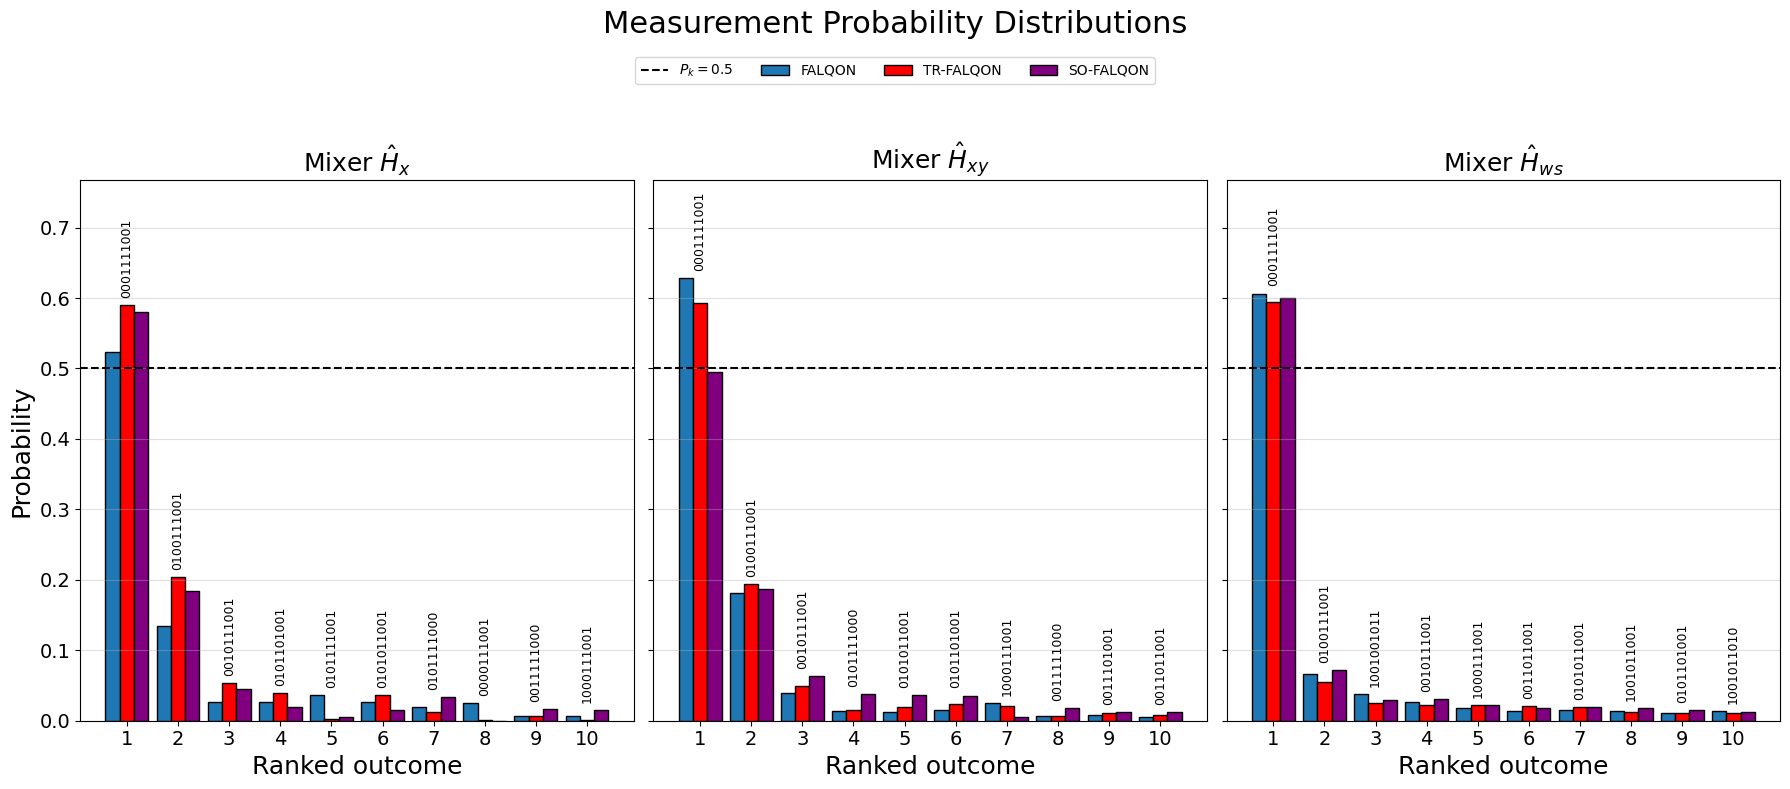

In [ ]:
#@title Comparison — Three Bars per Outcome (Ranks 1 to 10)

ALGORITHMS = [
    "FALQON",
    "TR-FALQON",
    "SO-FALQON"
]

MIXERS = [
    ("Hx", r"Mixer $\hat H_x$"),
    ("Hxy", r"Mixer $\hat H_{xy}$"),
    ("Hws", r"Mixer $\hat H_{ws}$")
]

ALGORITHM_COLORS = {
    "FALQON": "C0",
    "TR-FALQON": "red",
    "SO-FALQON": "purple"
}

# ======================================================
# Organize previously generated results
# Requires: distribution_results
# ======================================================
result_lookup = {
    (
        result["configuration"]["algorithm"],
        result["configuration"]["mixer"]
    ): result["distribution"]
    for result in distribution_results
}

# ======================================================
# Build a common ranking for each mixer
# Rank 1 = P_k
# Ranks 2..10 = top 9 non-ground bitstrings selected
# from the union of the three algorithm distributions
# ======================================================
def build_mixer_comparison(
    mixer_key,
    number_of_non_ground_states=9
):
    mixer_distributions = {
        algorithm: result_lookup[(algorithm, mixer_key)]
        for algorithm in ALGORITHMS
    }

    # Rank 1: total ground-state probability P_k
    ground_probabilities = {
        algorithm: distribution.loc[
            distribution["is_ground_state"],
            "probability"
        ].sum()
        for algorithm, distribution in mixer_distributions.items()
    }

    # Candidate non-ground states from all three variants
    non_ground_frames = []

    for algorithm, distribution in mixer_distributions.items():
        temp_df = distribution.loc[
            ~distribution["is_ground_state"],
            ["bitstring", "probability"]
        ].copy()

        temp_df["algorithm"] = algorithm
        non_ground_frames.append(temp_df)

    non_ground_df = pd.concat(
        non_ground_frames,
        ignore_index=True
    )

    probability_table = (
        non_ground_df
        .pivot_table(
            index="bitstring",
            columns="algorithm",
            values="probability",
            aggfunc="sum",
            fill_value=0.0
        )
    )

    for algorithm in ALGORITHMS:
        if algorithm not in probability_table.columns:
            probability_table[algorithm] = 0.0

    # Ranking criterion: highest probability attained
    # by any algorithm for that bitstring
    probability_table["ranking_score"] = (
        probability_table[ALGORITHMS]
        .max(axis=1)
    )

    selected_bitstrings = (
        probability_table
        .nlargest(
            number_of_non_ground_states,
            "ranking_score"
        )
        .index
        .tolist()
    )

    ground_bitstring = (
    mixer_distributions["FALQON"]
    .loc[
        mixer_distributions["FALQON"]["is_ground_state"],
        "bitstring"
    ].iloc[0]
    )

    plot_rows = [
        {
            "rank": 1,
            "label_above": ground_bitstring,
            **ground_probabilities
        }
    ]
    # plot_rows = []

    for rank, bitstring in enumerate(selected_bitstrings, start=2):
        # print(rank, bitstring)
        plot_rows.append(
            {
                "rank": rank,
                "label_above": bitstring,
                **{
                    algorithm: probability_table.loc[bitstring, algorithm]
                    for algorithm in ALGORITHMS
                }
            }
        )

    return pd.DataFrame(plot_rows)

comparison_data = {
    mixer_key: build_mixer_comparison(mixer_key)
    for mixer_key, _ in MIXERS
}

comparison_plot_df = pd.concat(
    [
        dataframe.assign(mixer=mixer_key)
        for mixer_key, dataframe in comparison_data.items()
    ],
    ignore_index=True
)

# CSV export intentionally disabled
comparison_plot_df.to_csv(
    "measurement_probability_grouped_bars_ranks.csv",
    index=False
)

# ======================================================
# Plot configuration
# ======================================================
fig, axs = plt.subplots(
    1,
    3,
    figsize=(18, 8),
    sharey=True
)

TITLE_SIZE    = 18
SUPTITLE_SIZE = 22
XLABEL_SIZE   = 18
YLABEL_SIZE   = 18
LEGEND_SIZE   = 10
TICK_SIZE     = 14

bar_width = 0.28

bar_offsets = {
    "FALQON": -bar_width,
    "TR-FALQON": 0.0,
    "SO-FALQON": bar_width
}

global_maximum = max(
    dataframe[ALGORITHMS].to_numpy().max()
    for dataframe in comparison_data.values()
)

upper_limit = min(
    1.05,
    max(0.57, global_maximum * 1.22)
)

# ======================================================
# Generate panels
# ======================================================
for column, (mixer_key, mixer_title) in enumerate(MIXERS):

    ax = axs[column]
    plot_df = comparison_data[mixer_key]

    ranks = plot_df["rank"].to_numpy()

    # Three thin bars per rank
    for algorithm in ALGORITHMS:
        ax.bar(
            ranks + bar_offsets[algorithm],
            plot_df[algorithm],
            width=bar_width,
            color=ALGORITHM_COLORS[algorithm],
            edgecolor="black",
            label=algorithm
        )

    # Reference line
    ax.axhline(
        0.5,
        linestyle="--",
        color="black",
        label=r"$P_k=0.5$"
    )

    ax.set_title(
        mixer_title,
        fontsize=TITLE_SIZE
    )

    ax.set_xlabel(
        "Ranked outcome",
        fontsize=XLABEL_SIZE
    )

    if column == 0:
        ax.set_ylabel(
            "Probability",
            fontsize=YLABEL_SIZE
        )

    # x-axis as ranks 1..10
    ax.set_xticks(ranks)
    ax.set_xticklabels(ranks)

    ax.set_ylim(0, upper_limit)

    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE
    )

    ax.grid(
        axis="y",
        alpha=0.4
    )

    # One label per rank group (centered)
    for _, row in plot_df.iterrows():

        rank = row["rank"]

        group_max = max(
            row["FALQON"],
            row["TR-FALQON"],
            row["SO-FALQON"]
        )

        ax.text(
            rank,
            group_max + 0.01,
            row["label_above"],
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=9
        )

fig.suptitle(
    "Measurement Probability Distributions",
    fontsize=SUPTITLE_SIZE
)

handles, labels = axs[0].get_legend_handles_labels()

# remove duplicate labels
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=4,
    fontsize=LEGEND_SIZE
)

plt.tight_layout(
    rect=[0, 0, 1, 0.89]
)

# plt.savefig(
#     "measurement_probability_grouped_bars.pdf",
#     bbox_inches="tight"
# )

plt.show()

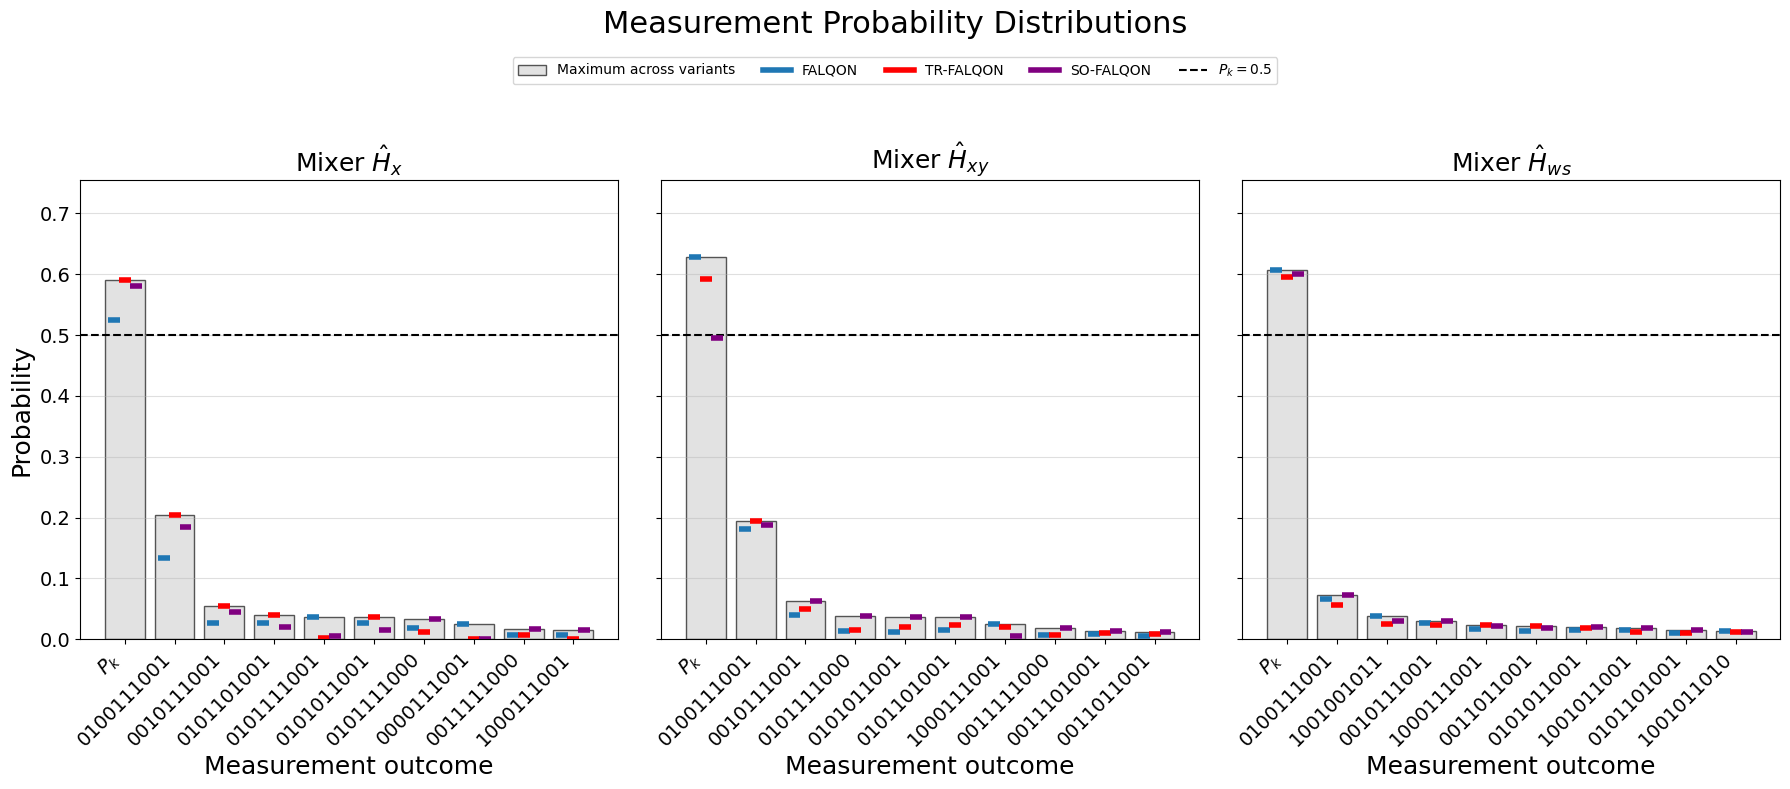

In [ ]:
#@title Comparison — Base Bars with Colored Probability Lines

ALGORITHMS = [
    "FALQON",
    "TR-FALQON",
    "SO-FALQON"
]

MIXERS = [
    ("Hx", r"Mixer $\hat H_x$"),
    ("Hxy", r"Mixer $\hat H_{xy}$"),
    ("Hws", r"Mixer $\hat H_{ws}$")
]

ALGORITHM_COLORS = {
    "FALQON": "C0",
    "TR-FALQON": "red",
    "SO-FALQON": "purple"
}

# ======================================================
# Organize previously generated results
# ======================================================
result_lookup = {
    (
        result["configuration"]["algorithm"],
        result["configuration"]["mixer"]
    ): result["distribution"]
    for result in distribution_results
}

# ======================================================
# Create common outcomes for the three algorithms
# ======================================================
def build_mixer_comparison(
    mixer_key,
    number_of_non_ground_states=9
):
    mixer_distributions = {
        algorithm: result_lookup[
            (algorithm, mixer_key)
        ]
        for algorithm in ALGORITHMS
    }

    ground_probabilities = {
        algorithm: distribution.loc[
            distribution["is_ground_state"],
            "probability"
        ].sum()
        for algorithm, distribution
        in mixer_distributions.items()
    }

    non_ground_frames = []

    for algorithm, distribution in (
        mixer_distributions.items()
    ):
        temporary_df = distribution.loc[
            ~distribution["is_ground_state"],
            ["bitstring", "probability"]
        ].copy()

        temporary_df["algorithm"] = algorithm
        non_ground_frames.append(temporary_df)

    non_ground_df = pd.concat(
        non_ground_frames,
        ignore_index=True
    )

    probability_table = (
        non_ground_df
        .pivot_table(
            index="bitstring",
            columns="algorithm",
            values="probability",
            aggfunc="sum",
            fill_value=0
        )
    )

    for algorithm in ALGORITHMS:
        if algorithm not in probability_table.columns:
            probability_table[algorithm] = 0.0

    probability_table["ranking_score"] = (
        probability_table[ALGORITHMS]
        .max(axis=1)
    )

    selected_bitstrings = (
        probability_table
        .nlargest(
            number_of_non_ground_states,
            "ranking_score"
        )
        .index
        .tolist()
    )

    plot_rows = [
        {
            "outcome": r"$P_k$",
            **ground_probabilities
        }
    ]

    for bitstring in selected_bitstrings:
        plot_rows.append(
            {
                "outcome": bitstring,
                **{
                    algorithm:
                    probability_table.loc[
                        bitstring,
                        algorithm
                    ]
                    for algorithm in ALGORITHMS
                }
            }
        )

    plot_df = pd.DataFrame(plot_rows)

    plot_df["base_height"] = (
        plot_df[ALGORITHMS]
        .max(axis=1)
    )

    return plot_df


comparison_data = {
    mixer_key: build_mixer_comparison(
        mixer_key
    )
    for mixer_key, _ in MIXERS
}

comparison_plot_df = pd.concat(
    [
        dataframe.assign(mixer=mixer_key)
        for mixer_key, dataframe
        in comparison_data.items()
    ],
    ignore_index=True
)

# CSV export intentionally disabled
# comparison_plot_df.to_csv(
#     "measurement_probability_base_bars.csv",
#     index=False
# )

# ======================================================
# Plot configuration
# ======================================================
fig, axs = plt.subplots(
    1,
    3,
    figsize=(18, 8),
    sharey=True
)

TITLE_SIZE    = 18
SUPTITLE_SIZE = 22
XLABEL_SIZE   = 18
YLABEL_SIZE   = 18
LEGEND_SIZE   = 10
TICK_SIZE     = 14

line_segments = {
    "FALQON": (-0.34, -0.10),
    "TR-FALQON": (-0.12, 0.12),
    "SO-FALQON": (0.10, 0.34)
}

global_maximum = max(
    dataframe[ALGORITHMS]
    .to_numpy()
    .max()
    for dataframe in comparison_data.values()
)

upper_limit = min(
    1.05,
    max(
        0.57,
        global_maximum * 1.20
    )
)

# ======================================================
# Generate panels
# ======================================================
for column, (
    mixer_key,
    mixer_title
) in enumerate(MIXERS):

    ax = axs[column]
    plot_df = comparison_data[mixer_key]

    positions = np.arange(
        len(plot_df)
    )

    # Base bar corresponds to the maximum value
    # among the three FALQON variants
    ax.bar(
        positions,
        plot_df["base_height"],
        width=0.8,
        color="lightgray",
        edgecolor="black",
        alpha=0.65,
        label="Maximum across variants"
    )

    # Colored probability lines
    for algorithm in ALGORITHMS:

        left_offset, right_offset = (
            line_segments[algorithm]
        )

        for position, probability in zip(
            positions,
            plot_df[algorithm]
        ):
            ax.hlines(
                y=probability,
                xmin=position + left_offset,
                xmax=position + right_offset,
                color=ALGORITHM_COLORS[
                    algorithm
                ],
                linewidth=4,
                zorder=3
            )

    ax.axhline(
        0.5,
        linestyle="--",
        color="black"
    )

    ax.set_title(
        mixer_title,
        fontsize=TITLE_SIZE
    )

    ax.set_xlabel(
        "Measurement outcome",
        fontsize=XLABEL_SIZE
    )

    if column == 0:
        ax.set_ylabel(
            "Probability",
            fontsize=YLABEL_SIZE
        )

    ax.set_xticks(positions)

    ax.set_xticklabels(
        plot_df["outcome"],
        rotation=45,
        ha="right"
    )

    ax.set_ylim(
        0,
        upper_limit
    )

    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE
    )

    ax.grid(
        axis="y",
        alpha=0.4
    )

legend_elements = [
    Patch(
        facecolor="lightgray",
        edgecolor="black",
        alpha=0.65,
        label="Maximum across variants"
    ),
    Line2D(
        [0],
        [0],
        color="C0",
        linewidth=4,
        label="FALQON"
    ),
    Line2D(
        [0],
        [0],
        color="red",
        linewidth=4,
        label="TR-FALQON"
    ),
    Line2D(
        [0],
        [0],
        color="purple",
        linewidth=4,
        label="SO-FALQON"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        label=r"$P_k=0.5$"
    )
]

fig.suptitle(
    "Measurement Probability Distributions",
    fontsize=SUPTITLE_SIZE
)

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=5,
    fontsize=LEGEND_SIZE
)

plt.tight_layout(
    rect=[0, 0, 1, 0.89]
)

# plt.savefig(
#     "measurement_probability_base_bars.pdf",
#     bbox_inches="tight"
# )

plt.show()

# Execução

## FALQON

In [ ]:
#@title FALQON
dt = 1.8
layers = 500
beta0 = 0
Hd = qtsuru.Hx(L, device=device)
psi_x, energias_x, betas_x, prob_x = qtsuru.falqon(Hp, Hd, psi0_x, dt, layers, beta0, psi_x, True, estados, print_interval=100)

Layer 100, E = 0.004951297538096134
Layer 200, E = -0.00028587866234290637
Layer 300, E = -0.002466386214094478
Layer 400, E = -0.0035079291665673085
Layer 500, E = -0.004417137862630547


In [ ]:
#@title FALQON XY
dt = 3
layers = 500
beta0 = 0
alpha = 20
Hd = Hxy(L, alpha, device)
psi_xy, energias_xy, betas_xy, prob_xy = qtsuru.falqon(Hp, Hd, psi0_xy, dt, layers, beta0, psi_xy, True, estados, print_interval=100)


Layer 100, E = -0.003969171841141454
Layer 200, E = -0.005432608096945405
Layer 300, E = -0.006207150118623108
Layer 400, E = -0.0064688198241257345
Layer 500, E = -0.0064967492467147715


In [ ]:
#@title FALQON Warm
dt = 4
layers = 500
beta0 = 0
Hd = Hwarm(L, c_stars, epsilon, device=device)
psi_warm, energias_warm, betas_warm, prob_warm = qtsuru.falqon(Hp, Hd, psi0_warm, dt, layers, beta0, psi_warm, True, estados, print_interval=100)


Layer 100, E = 0.020863107430198192
Layer 200, E = 0.01675955583093556
Layer 300, E = 0.015828896608129306
Layer 400, E = 0.01532478126424362
Layer 500, E = 0.014855784163864896


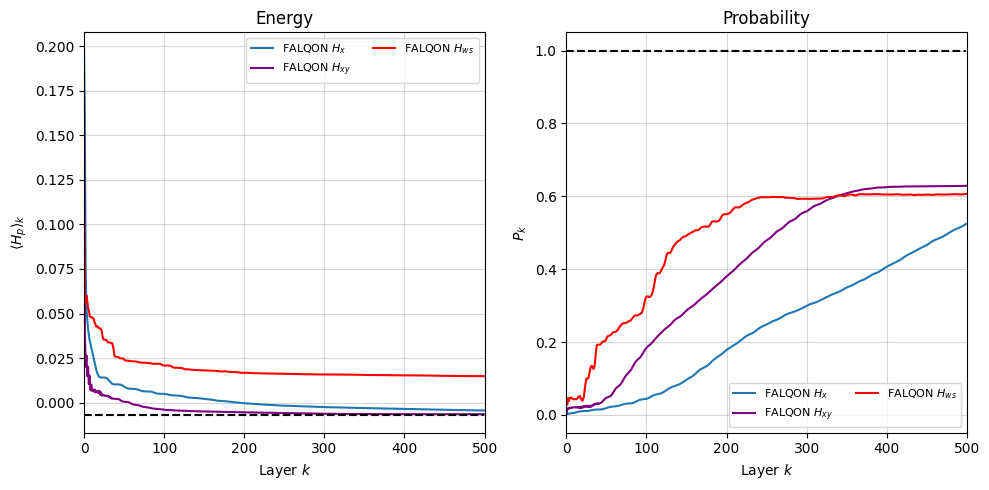

In [ ]:
#@title Gráfico (FALQON)

fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

# ======================================================
# Coluna 1 — Energy (FALQON)
# ======================================================
axs[0].plot(energias_x,     label=r"FALQON $H_x$")
axs[0].plot(energias_xy,    label=r"FALQON $H_{xy}$",  color="purple")
axs[0].plot(energias_warm,  label=r"FALQON $H_{ws}$",  color="red")

axs[0].plot(np.ones(len(energias_xy)) * float(emin), "--", color="black")
axs[0].set_ylabel(r"$\langle H_p \rangle_k$")
axs[0].set_title("Energy")
axs[0].grid(alpha=0.5)
axs[0].legend(fontsize=8, ncol=2)

# ======================================================
# Coluna 2 — Probability (FALQON)
# ======================================================
axs[1].plot(prob_x,     label=r"FALQON $H_x$")
axs[1].plot(prob_xy,    label=r"FALQON $H_{xy}$",  color="purple")
axs[1].plot(prob_warm,  label=r"FALQON $H_{ws}$",  color="red")

axs[1].plot(np.ones(len(prob_xy)), "--", color="black")
axs[1].set_ylabel(r"$P_k$")
axs[1].set_title("Probability")
axs[1].grid(alpha=0.5)
axs[1].legend(fontsize=8, ncol=2)

# ======================================================
# Ajustes finais
# ======================================================
for j in range(2):
    axs[j].set_xlim(0, layers)
    axs[j].set_xlabel(r"Layer $k$")

plt.tight_layout()
plt.show()


## FALQON TR

In [ ]:
#@title FALQON TR
dt = 1.5
layers = 500
beta0 = 0
a = 6
tf = dt * layers * a * 5
args = [tf, a]
beta0 = 0
df = qtsuru.fqas.df1
Hd = qtsuru.Hx(L, device=device)
trpsi, trenergia, trbeta, trprob = qtsuru.trfalqon(Hp, Hd, psi0_x, dt, layers, df, args, beta0, psi_x, True, estados, 100)


Layer 100, E = 0.005477758084123694
Layer 200, E = -0.0008497688914274658
Layer 300, E = -0.004375923698750087
Layer 400, E = -0.006318115855604206
Layer 500, E = -0.006654432342983496


In [ ]:
#@title FALQON TR - Warm
dt = 5
layers = 500
beta0 = 0
a = 1
tf = dt * layers * a * 5
args = [tf, a]
beta0 = 0
df = qtsuru.fqas.df1
Hd = Hwarm(L, c_stars, epsilon, device=device)
trpsi_warm, trenergia_warm, trbeta_warm, trprob_warm = qtsuru.trfalqon(Hp, Hd, psi0_warm, dt, layers, df, args, beta0, psi_warm, True, estados, 100)


Layer 100, E = 0.02899541663128558
Layer 200, E = 0.026324984747421315
Layer 300, E = 0.025788753492325886
Layer 400, E = 0.02543045965328971
Layer 500, E = 0.024983309336648624


In [ ]:
#@title FALQON TR - XY
dt = 3
layers = 500
beta0 = 0
a = 2
tf = dt * layers * a * 5
args = [tf, a]
beta0 = 0
df = qtsuru.fqas.df1
alpha = 20
Hd = Hxy(L, alpha, device)
trpsi_xy, trenergia_xy, trbeta_xy, trprob_xy = qtsuru.trfalqon(Hp, Hd, psi0_xy, dt, layers, df, args, beta0, psi_xy, True, estados, 100)


Layer 100, E = -0.003989059291927292
Layer 200, E = -0.005478396901563643
Layer 300, E = -0.006277301968820459
Layer 400, E = -0.00638874029214513
Layer 500, E = -0.006422267112727687


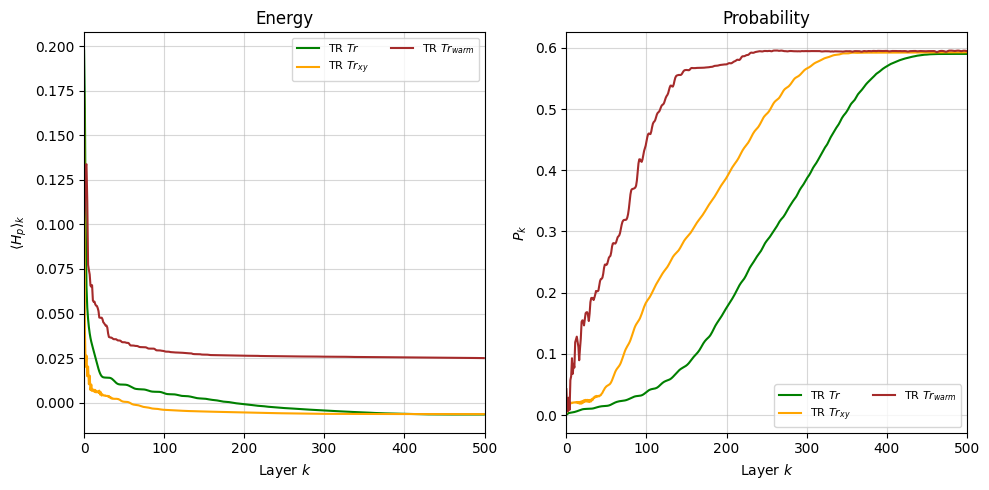

In [ ]:
#@title Gráfico (TR)

fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

# ======================================================
# Coluna 1 — Energy (TR)
# ======================================================
axs[0].plot(trenergia,      label=r"TR $Tr$",          color="green")
axs[0].plot(trenergia_xy,   label=r"TR $Tr_{xy}$",     color="orange")
axs[0].plot(trenergia_warm, label=r"TR $Tr_{warm}$",   color="brown")

# axs[0].plot(np.ones(len(energias_xy)) * float(emin), "--", color="black")
axs[0].set_ylabel(r"$\langle H_p \rangle_k$")
axs[0].set_title("Energy")
axs[0].grid(alpha=0.5)
axs[0].legend(fontsize=8, ncol=2)

# ======================================================
# Coluna 2 — Probability (TR)
# ======================================================
axs[1].plot(trprob,     label=r"TR $Tr$",          color="green")
axs[1].plot(trprob_xy,  label=r"TR $Tr_{xy}$",     color="orange")
axs[1].plot(trprob_warm,label=r"TR $Tr_{warm}$",   color="brown")

# axs[1].plot(np.ones(len(prob_xy)), "--", color="black")
axs[1].set_ylabel(r"$P_k$")
axs[1].set_title("Probability")
axs[1].grid(alpha=0.5)
axs[1].legend(fontsize=8, ncol=2)

# ======================================================
# Ajustes finais
# ======================================================
for j in range(2):
    axs[j].set_xlim(0, layers)
    axs[j].set_xlabel(r"Layer $k$")

plt.tight_layout()
plt.show()


## FALQON SO

In [ ]:
#@title FALQON SO
dt = 3
layers = 500
beta0 = 0
Hd = qtsuru.Hx(L, device=device)
sopsi, soenergia, sobeta, soprob = qtsuru.sofalqon(Hp, Hd, psi0_x, dt, layers, beta0, True, psi_x, True, estados, 100)


Layer 100, E = 0.00170278088604775
Layer 200, E = -0.002990774421385795
Layer 300, E = -0.004229327509055433
Layer 400, E = -0.004919056446946278
Layer 500, E = -0.005181325345952402


In [ ]:
#@title FALQON SO - Warm
dt = 5
layers = 500
beta0 = 0
Hd = Hwarm(L, c_stars, epsilon, device=device)
sopsi_warm, soenergia_warm, sobeta_warm, soprob_warm = qtsuru.sofalqon(Hp, Hd, psi0_warm, dt, layers, beta0, True, psi_warm, True, estados, 100)


Layer 100, E = 0.016553517950521894
Layer 200, E = 0.013909439168345101
Layer 300, E = 0.013345466289441298
Layer 400, E = 0.012973328464797136
Layer 500, E = 0.012376393393691596


In [ ]:
#@title FALQON SO - XY
dt = 1.4
layers = 500
beta0 = 0
alpha = 3
Hd = Hxy(L, alpha, device)
sopsi_xy, soenergia_xy, sobeta_xy, soprob_xy = qtsuru.sofalqon(Hp, Hd, psi0_xy, dt, layers, beta0, True, psi_xy, True, estados, 100)

Layer 100, E = 0.008689031523523781
Layer 200, E = 0.004629408031606052
Layer 300, E = 0.0034110779471191203
Layer 400, E = 0.0029649832731298963
Layer 500, E = 0.0025356968098684787


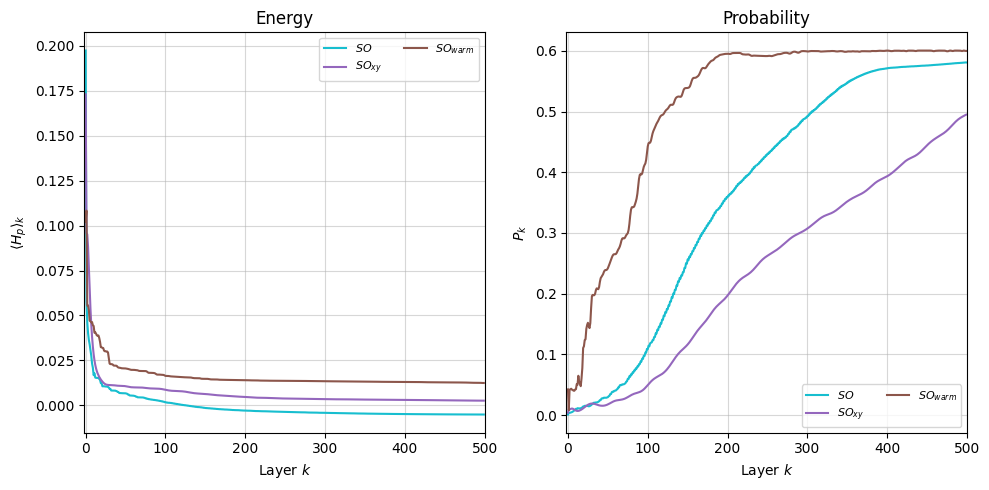

In [ ]:
#@title Gráfico (SO)

fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

# ======================================================
# Coluna 1 — Energy (SO)
# ======================================================
axs[0].plot(soenergia,      label=r"$SO$",          color="#17becf")
axs[0].plot(soenergia_xy,   label=r"$SO_{xy}$",     color="#9467bd")
axs[0].plot(soenergia_warm, label=r"$SO_{warm}$",   color="#8c564b")

# axs[0].plot(np.ones(len(energias_xy)) * float(emin), "--", color="black")
axs[0].set_ylabel(r"$\langle H_p \rangle_k$")
axs[0].set_title("Energy")
axs[0].grid(alpha=0.5)
axs[0].legend(fontsize=8, ncol=2)

# ======================================================
# Coluna 2 — Probability (SO)
# ======================================================
axs[1].plot(soprob,     label=r"$SO$",          color="#17becf")
axs[1].plot(soprob_xy,  label=r"$SO_{xy}$",     color="#9467bd")
axs[1].plot(soprob_warm,label=r"$SO_{warm}$",   color="#8c564b")

# axs[1].plot(np.ones(len(prob_xy)), "--", color="black")
axs[1].set_ylabel(r"$P_k$")
axs[1].set_title("Probability")
axs[1].grid(alpha=0.5)
axs[1].legend(fontsize=8, ncol=2)

# ======================================================
# Ajustes finais
# ======================================================
for j in range(2):
    axs[j].set_xlim(-2, layers)
    axs[j].set_xlabel(r"Layer $k$")

plt.tight_layout()
plt.show()


# Plot

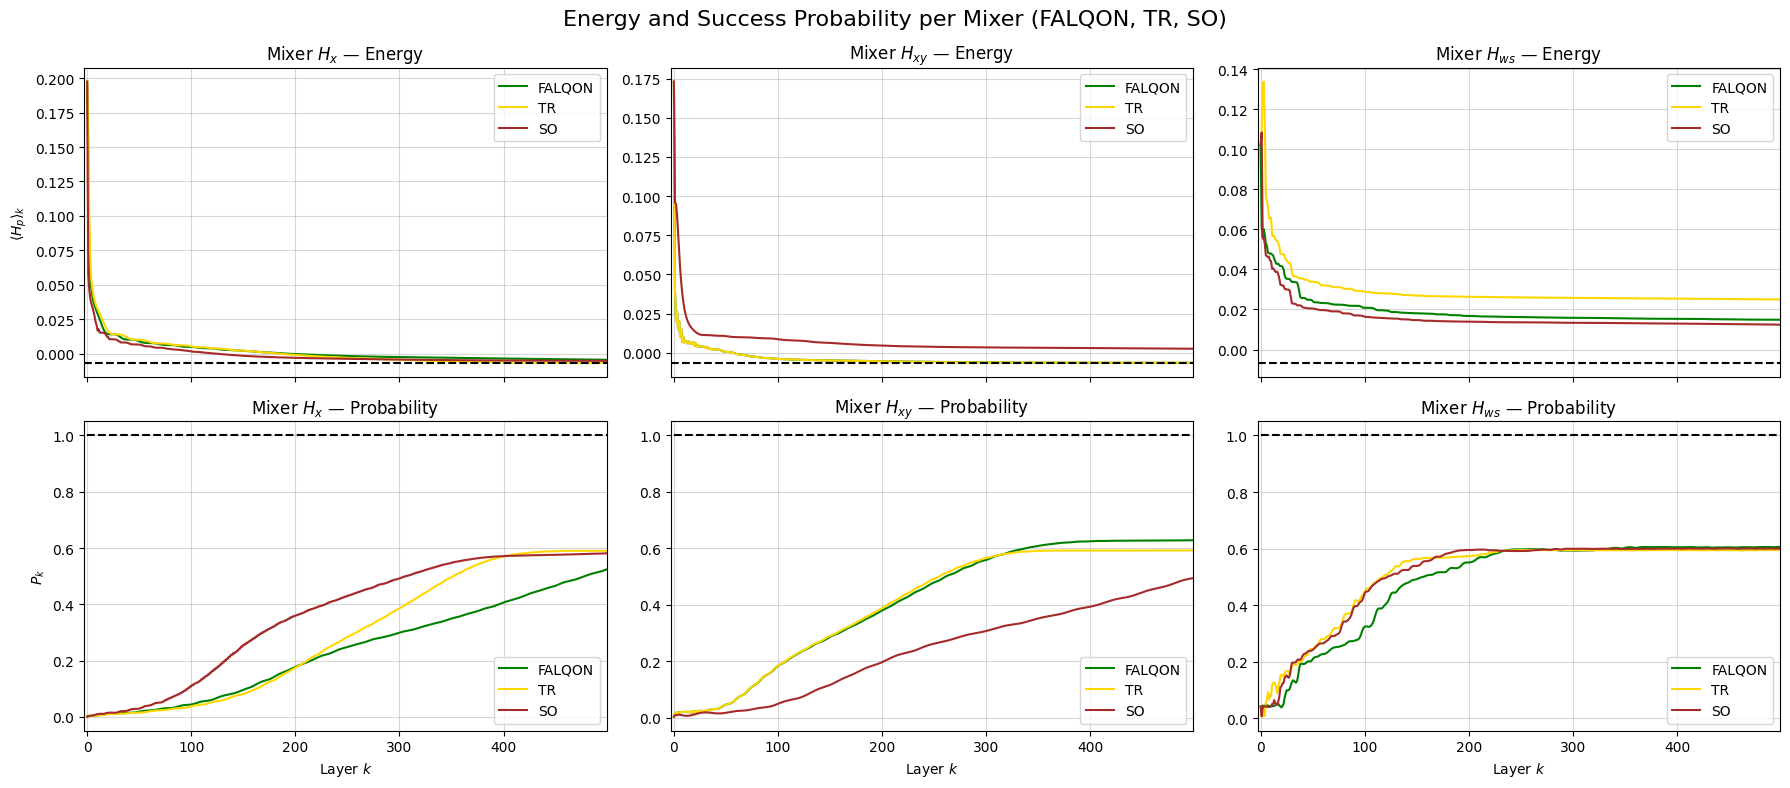

In [ ]:
#@title Gráfico (Energy & Probability — 3 Mixers)

fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharex=True)

# Colors
c_falqon = "green"
c_tr     = "gold"
c_so     = "brown"

# Column 1 — Mixer X
axs[0, 0].plot(energias_x, label="FALQON", color=c_falqon)
axs[0, 0].plot(trenergia,  label="TR",     color=c_tr)
axs[0, 0].plot(soenergia,  label="SO",     color=c_so)
axs[0, 0].axhline(float(emin), ls="--", color="black")
axs[0, 0].set_ylabel(r"$\langle H_p \rangle_k$")
axs[0, 0].set_title(r"Mixer $H_x$ — Energy")
axs[0, 0].legend(fontsize=10)
axs[0, 0].grid(alpha=0.5)

axs[1, 0].plot(prob_x, label="FALQON", color=c_falqon)
axs[1, 0].plot(trprob, label="TR",     color=c_tr)
axs[1, 0].plot(soprob, label="SO",     color=c_so)
axs[1, 0].plot(np.ones(len(prob_x)), "--", color="black")
axs[1, 0].set_ylabel(r"$P_k$")
axs[1, 0].set_xlabel(r"Layer $k$")
axs[1, 0].set_title(r"Mixer $H_x$ — Probability")
axs[1, 0].legend(fontsize=10)
axs[1, 0].grid(alpha=0.5)

# Column 2 — Mixer XY
axs[0, 1].plot(energias_xy,  label="FALQON", color=c_falqon)
axs[0, 1].plot(trenergia_xy, label="TR",     color=c_tr)
axs[0, 1].plot(soenergia_xy, label="SO",     color=c_so)
axs[0, 1].axhline(float(emin), ls="--", color="black")
axs[0, 1].set_title(r"Mixer $H_{xy}$ — Energy")
axs[0, 1].legend(fontsize=10)
axs[0, 1].grid(alpha=0.5)

axs[1, 1].plot(prob_xy,   label="FALQON", color=c_falqon)
axs[1, 1].plot(trprob_xy, label="TR",     color=c_tr)
axs[1, 1].plot(soprob_xy, label="SO",     color=c_so)
axs[1, 1].plot(np.ones(len(prob_xy)), "--", color="black")
axs[1, 1].set_xlabel(r"Layer $k$")
axs[1, 1].set_title(r"Mixer $H_{xy}$ — Probability")
axs[1, 1].legend(fontsize=10)
axs[1, 1].grid(alpha=0.5)

# Column 3 — Mixer Warm
axs[0, 2].plot(energias_warm,  label="FALQON", color=c_falqon)
axs[0, 2].plot(trenergia_warm, label="TR",     color=c_tr)
axs[0, 2].plot(soenergia_warm, label="SO",     color=c_so)
axs[0, 2].axhline(float(emin), ls="--", color="black")
axs[0, 2].set_title(r"Mixer $H_{ws}$ — Energy")
axs[0, 2].legend(fontsize=10)
axs[0, 2].grid(alpha=0.5)

axs[1, 2].plot(prob_warm,   label="FALQON", color=c_falqon)
axs[1, 2].plot(trprob_warm, label="TR",     color=c_tr)
axs[1, 2].plot(soprob_warm, label="SO",     color=c_so)
axs[1, 2].plot(np.ones(len(prob_warm)), "--", color="black")
axs[1, 2].set_xlabel(r"Layer $k$")
axs[1, 2].set_title(r"Mixer $H_{ws}$ — Probability")
axs[1, 2].legend(fontsize=10)
axs[1, 2].grid(alpha=0.5)

for i in range(2):
    for j in range(3):
        axs[i, j].set_xlim(-3, layers - 1)

fig.suptitle("Energy and Success Probability per Mixer (FALQON, TR, SO)", fontsize=16)

plt.savefig("energy_probability_3_mixers_10_assets.pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

def to_1d(x):
    return np.asarray(x).reshape(-1)

layers_idx = np.arange(layers)

data = {
    "layer": layers_idx,

    # Mixer Hx — Energy
    "E_falqon_x": to_1d(energias_x),
    "E_tr_x":     to_1d(trenergia),
    "E_so_x":     to_1d(soenergia),

    # Mixer Hx — Probability
    "P_falqon_x": to_1d(prob_x),
    "P_tr_x":     to_1d(trprob),
    "P_so_x":     to_1d(soprob),

    # Mixer Hxy — Energy
    "E_falqon_xy": to_1d(energias_xy),
    "E_tr_xy":     to_1d(trenergia_xy),
    "E_so_xy":     to_1d(soenergia_xy),

    # Mixer Hxy — Probability
    "P_falqon_xy": to_1d(prob_xy),
    "P_tr_xy":     to_1d(trprob_xy),
    "P_so_xy":     to_1d(soprob_xy),

    # Mixer Hws — Energy
    "E_falqon_warm": to_1d(energias_warm),
    "E_tr_warm":     to_1d(trenergia_warm),
    "E_so_warm":     to_1d(soenergia_warm),

    # Mixer Hws — Probability
    "P_falqon_warm": to_1d(prob_warm),
    "P_tr_warm":     to_1d(trprob_warm),
    "P_so_warm":     to_1d(soprob_warm),
}

df = pd.DataFrame(data)
df.to_csv("energy_probability_3_mixers_10_assets.csv", index=False)


In [ ]:
df

,layer,E_falqon_x,E_tr_x,E_so_x,P_falqon_x,P_tr_x,P_so_x,E_falqon_xy,E_tr_xy,E_so_xy,P_falqon_xy,P_tr_xy,P_so_xy,E_falqon_warm,E_tr_warm,E_so_warm,P_falqon_warm,P_tr_warm,P_so_warm
0,0,0.197475,0.197475,0.197475,0.000977,0.000977,0.000977,0.173104,0.173104,0.173104,0.003968,0.003968,0.003968,0.102075,0.102075,0.102075,0.042333,0.042333,0.042333
1,1,0.145109,0.165151,0.057925,0.001815,0.001454,0.003512,0.040728,0.040728,0.095939,0.014333,0.014333,0.009248,0.061399,0.108342,0.108342,0.028091,0.008152,0.008152
2,2,0.072794,0.102642,0.046201,0.003286,0.002676,0.003713,0.020134,0.020133,0.095129,0.018347,0.018347,0.009317,0.056184,0.132797,0.055416,0.045908,0.006321,0.041750
3,3,0.053208,0.065198,0.040121,0.003613,0.003402,0.004026,0.026379,0.026379,0.088071,0.016670,0.016670,0.009885,0.060082,0.133721,0.055548,0.037504,0.028472,0.042520
4,4,0.046603,0.053177,0.036331,0.003774,0.003616,0.004470,0.014829,0.014829,0.076392,0.019748,0.019748,0.010555,0.057111,0.112669,0.052836,0.046168,0.008574,0.043444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,495,-0.004365,-0.006654,-0.005175,0.518486,0.590037,0.580411,-0.006491,-0.006420,0.002543,0.628378,0.592543,0.492028,0.014898,0.025002,0.012449,0.605544,0.595112,0.599995
496,496,-0.004376,-0.006654,-0.005179,0.519794,0.590003,0.580660,-0.006492,-0.006420,0.002541,0.628458,0.592557,0.492735,0.014891,0.024997,0.012411,0.605859,0.595290,0.600448
497,497,-0.004389,-0.006654,-0.005178,0.521171,0.589995,0.580640,-0.006493,-0.006421,0.002540,0.628556,0.592598,0.493434,0.014878,0.024998,0.012382,0.606181,0.595307,0.600295
498,498,-0.004403,-0.006654,-0.005182,0.522589,0.589996,0.580880,-0.006495,-0.006422,0.002538,0.628660,0.592653,0.494138,0.014864,0.024991,0.012376,0.606385,0.595159,0.599921


---

# Plots Finais


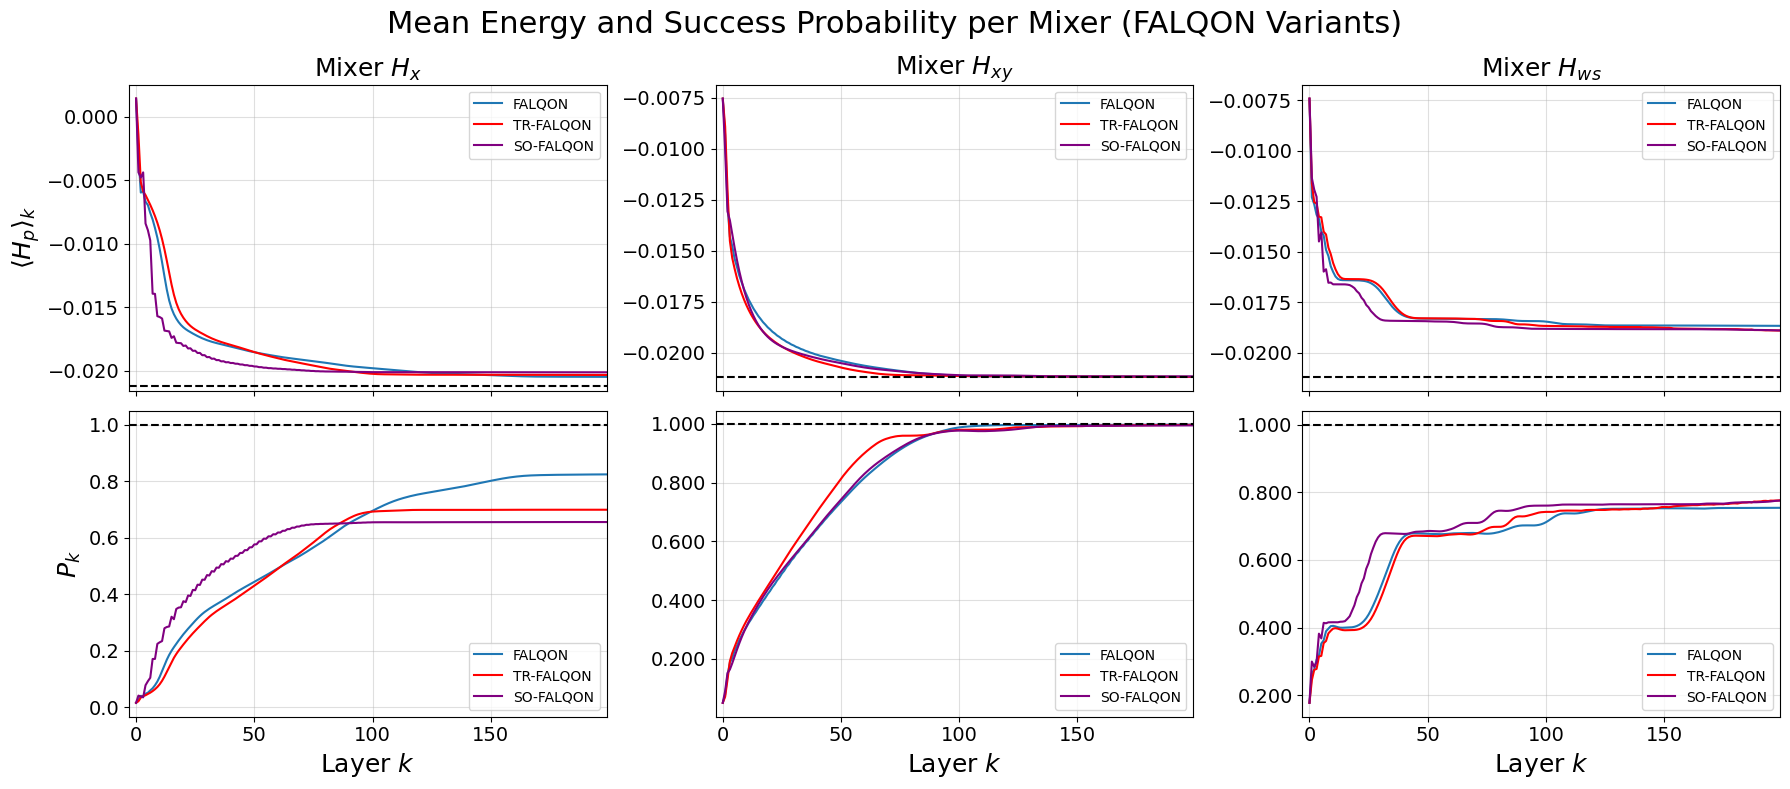

In [ ]:
#@title Mean Energy and Probability — CSV (Wide Format)

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# ======================================================
# Load CSV
# ======================================================
df = pd.read_csv("mean_energy_probability_mixers.csv")

layers = len(df)
emin   = df[
    [
        "E_falqon_x","E_tr_x","E_so_x",
        "E_falqon_xy","E_tr_xy","E_so_xy",
        "E_falqon_warm","E_tr_warm","E_so_warm",
    ]
].min().min()

# ======================================================
# Plot configuration
# ======================================================
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharex=True)

TITLE_SIZE    = 18
SUPTITLE_SIZE = 22
XLABEL_SIZE   = 18
YLABEL_SIZE   = 18
LEGEND_SIZE   = 10
TICK_SIZE     = 14

def plot_mixer_column(axE, axP, mixer_key, title, show_ylabel=False, format_prob_3dec=False):
    # ------------------ Energy ------------------
    axE.plot(df[f"E_falqon_{mixer_key}"], label="FALQON",    color="C0")
    axE.plot(df[f"E_tr_{mixer_key}"],     label="TR-FALQON", color="red")
    axE.plot(df[f"E_so_{mixer_key}"],     label="SO-FALQON", color="purple")
    axE.axhline(float(emin), ls="--", c="k")
    axE.set_title(title, fontsize=TITLE_SIZE)

    if show_ylabel:
        axE.set_ylabel(r"$\langle H_p \rangle_k$", fontsize=YLABEL_SIZE)
    else:
        axE.set_ylabel("")

    axE.legend(fontsize=LEGEND_SIZE)
    axE.grid(alpha=0.4)
    axE.tick_params(axis="both", labelsize=TICK_SIZE)

    # ---------------- Probability ----------------
    axP.plot(df[f"P_falqon_{mixer_key}"], label="FALQON",    color="C0")
    axP.plot(df[f"P_tr_{mixer_key}"],     label="TR-FALQON", color="red")
    axP.plot(df[f"P_so_{mixer_key}"],     label="SO-FALQON", color="purple")
    axP.axhline(1.0, ls="--", c="k")  # Pk = 1 reference

    if show_ylabel:
        axP.set_ylabel(r"$P_k$", fontsize=YLABEL_SIZE)
    else:
        axP.set_ylabel("")

    if format_prob_3dec:
        axP.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

    axP.set_xlabel("Layer $k$", fontsize=XLABEL_SIZE)
    axP.legend(fontsize=LEGEND_SIZE)
    axP.grid(alpha=0.4)
    axP.tick_params(axis="both", labelsize=TICK_SIZE)

# ======================================================
# Mixer Hx (LEFT — with labels)
# ======================================================
plot_mixer_column(
    axs[0, 0], axs[1, 0],
    mixer_key="x",
    title=r"Mixer $H_x$",
    show_ylabel=True,
    format_prob_3dec=False
)

# ======================================================
# Mixer Hxy (3 decimals on probability axis)
# ======================================================
plot_mixer_column(
    axs[0, 1], axs[1, 1],
    mixer_key="xy",
    title=r"Mixer $H_{xy}$",
    show_ylabel=False,
    format_prob_3dec=True
)

# ======================================================
# Mixer Hws (3 decimals on probability axis)
# ======================================================
plot_mixer_column(
    axs[0, 2], axs[1, 2],
    mixer_key="warm",
    title=r"Mixer $H_{ws}$",
    show_ylabel=False,
    format_prob_3dec=True
)

for i in range(2):
    for j in range(3):
        axs[i, j].set_xlim(-3, layers - 1)

fig.suptitle(
    "Mean Energy and Success Probability per Mixer (FALQON Variants)",
    fontsize=SUPTITLE_SIZE
)

plt.tight_layout()

plt.savefig("mean_energy_probability_mixers.pdf", bbox_inches="tight")

plt.show()


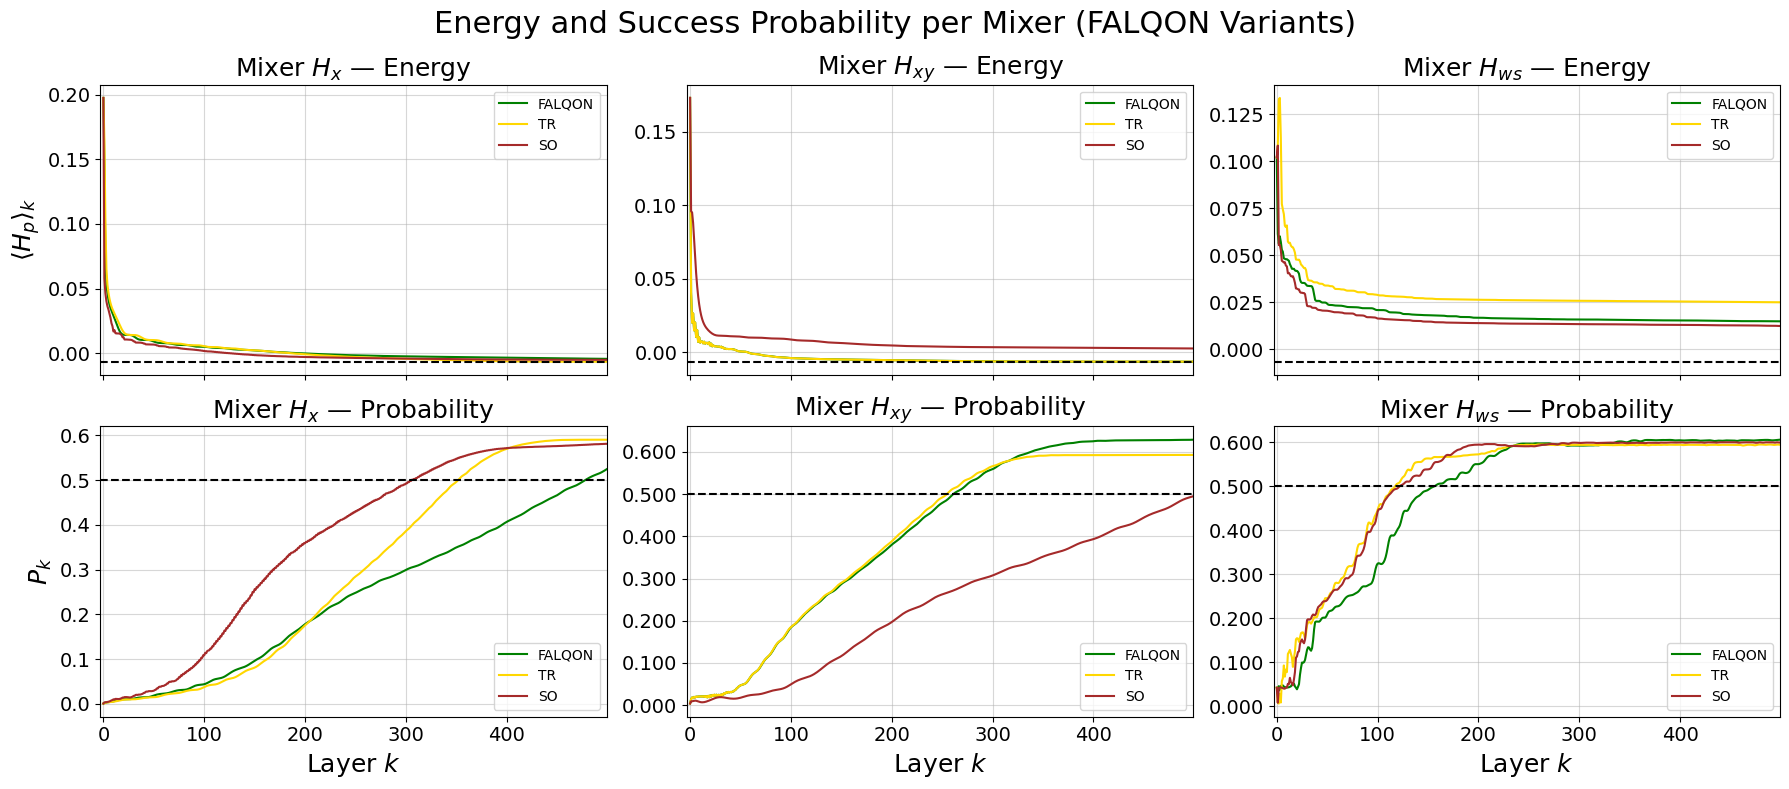

In [ ]:
#@title Energy & Probability — 3 Mixers (10 assets, CSV)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

# ======================================================
# Load CSV (wide format)
# ======================================================
df = pd.read_csv("energy_probability_3_mixers_10_assets.csv")

layers = len(df)

emin = df[
    [
        "E_falqon_x","E_tr_x","E_so_x",
        "E_falqon_xy","E_tr_xy","E_so_xy",
        "E_falqon_warm","E_tr_warm","E_so_warm",
    ]
].min().min()

# ======================================================
# Style parameters (fixed)
# ======================================================
TITLE_SIZE    = 18
SUPTITLE_SIZE = 22
XLABEL_SIZE   = 18
YLABEL_SIZE   = 18
LEGEND_SIZE   = 10
TICK_SIZE     = 14

# Colors
c_falqon = "green"
c_tr     = "gold"
c_so     = "brown"

# ======================================================
# Plot configuration
# ======================================================
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharex=True)

def plot_mixer(axE, axP, mixer_key, title_energy, title_prob,
               show_ylabel=False, format_prob_3dec=False):

    # ---------------- Energy ----------------
    axE.plot(df[f"E_falqon_{mixer_key}"], label="FALQON", color=c_falqon)
    axE.plot(df[f"E_tr_{mixer_key}"],     label="TR",     color=c_tr)
    axE.plot(df[f"E_so_{mixer_key}"],     label="SO",     color=c_so)
    axE.axhline(float(emin), ls="--", color="black")
    axE.set_title(title_energy, fontsize=TITLE_SIZE)

    if show_ylabel:
        axE.set_ylabel(r"$\langle H_p \rangle_k$", fontsize=YLABEL_SIZE)

    axE.legend(fontsize=LEGEND_SIZE)
    axE.grid(alpha=0.5)
    axE.tick_params(axis="both", labelsize=TICK_SIZE)

    # ---------------- Probability ----------------
    axP.plot(df[f"P_falqon_{mixer_key}"], label="FALQON", color=c_falqon)
    axP.plot(df[f"P_tr_{mixer_key}"],     label="TR",     color=c_tr)
    axP.plot(df[f"P_so_{mixer_key}"],     label="SO",     color=c_so)
    axP.axhline(0.5, ls="--", color="black")  # Pk = 0.5

    axP.set_title(title_prob, fontsize=TITLE_SIZE)
    axP.set_xlabel(r"Layer $k$", fontsize=XLABEL_SIZE)

    if show_ylabel:
        axP.set_ylabel(r"$P_k$", fontsize=YLABEL_SIZE)

    if format_prob_3dec:
        axP.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

    axP.legend(fontsize=LEGEND_SIZE)
    axP.grid(alpha=0.5)
    axP.tick_params(axis="both", labelsize=TICK_SIZE)

# ======================================================
# Mixer Hx
# ======================================================
plot_mixer(
    axs[0, 0], axs[1, 0],
    mixer_key="x",
    title_energy=r"Mixer $H_x$ — Energy",
    title_prob=r"Mixer $H_x$ — Probability",
    show_ylabel=True,
    format_prob_3dec=False
)

# ======================================================
# Mixer Hxy
# ======================================================
plot_mixer(
    axs[0, 1], axs[1, 1],
    mixer_key="xy",
    title_energy=r"Mixer $H_{xy}$ — Energy",
    title_prob=r"Mixer $H_{xy}$ — Probability",
    show_ylabel=False,
    format_prob_3dec=True
)

# ======================================================
# Mixer Hws
# ======================================================
plot_mixer(
    axs[0, 2], axs[1, 2],
    mixer_key="warm",
    title_energy=r"Mixer $H_{ws}$ — Energy",
    title_prob=r"Mixer $H_{ws}$ — Probability",
    show_ylabel=False,
    format_prob_3dec=True
)

# ======================================================
# Axes limits and global title
# ======================================================
for i in range(2):
    for j in range(3):
        axs[i, j].set_xlim(-3, layers - 1)

fig.suptitle(
    "Energy and Success Probability per Mixer (FALQON Variants)",
    fontsize=SUPTITLE_SIZE
)

plt.tight_layout()

plt.savefig("energy_probability_3_mixers_10_assets.pdf", bbox_inches="tight")

plt.show()
